
# Inspecting DiT (MNIST Modular Addition) — Intermediate Activations

This notebook loads the DiT model from the repo, uses pretrained weights (if available in `./weights`), constructs a small MNIST modular-addition batch (two input digits conditioned to produce their sum), **runs sampling**, and **captures intermediate activations** from each Transformer block for inspection.

**What you'll see:**
- How to register PyTorch forward hooks into `TransformerBlock`s
- Token-wise norms/means of the block outputs
- Example end-to-end sampling that produces a sum digit from two MNIST digits


In [1]:
import os, sys, glob, math, itertools, numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Make sure we can import from the uploaded files' directory
if '/mnt/data' not in sys.path:
    sys.path.append('/mnt/data')

from model import DiT_Llama, DiT_Llama_600M_patch2  # model architecture
from train import MNISTModularArithmeticDataset, RF  # dataset + sampler
from classifier import MNISTClassifier  # optional for accuracy check

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device


device(type='cuda')

In [2]:
# Try to locate a checkpoint under ./weights/** (e.g., weights/<exp>/model_final.pth or model_epoch_*.pth)
def find_checkpoint():
    # Priority: model_final.pth; fallback: last model_epoch_*.pth by epoch number
    final_ckpts = glob.glob('weights/**/model_final.pth', recursive=True)
    if len(final_ckpts) > 0:
        return sorted(final_ckpts)[-1]
    epoch_ckpts = glob.glob('weights/**/model_epoch_*.pth', recursive=True)
    if len(epoch_ckpts) > 0:
        # sort by epoch number embedded in filename
        def _epoch_num(p):
            import re
            m = re.search(r'model_epoch_(\d+)\.pth', os.path.basename(p))
            return int(m.group(1)) if m else -1
        epoch_ckpts.sort(key=_epoch_num)
        return epoch_ckpts[-1]
    return None

# Instantiate the DiT model with the same config used in training (train.py)
# model = DiT_Llama(
#     in_channels=1,      # target channel (MNIST grayscale)
#     input_size=32,
#     patch_size=2,
#     dim=256,
#     n_layers=10,
#     n_heads=8,
# ).to(device)

model = DiT_Llama(
    in_channels=3,      # target channel (MNIST grayscale)
    input_size=32,
    patch_size=2,
    dim=256,
    n_layers=10,
    n_heads=8,
).to(device)

# model = DiT_Llama_600M_patch2()

# model = model.to(device)

ckpt_path = "weights/train_fraction_0.9-num_images_1/model_epoch_29700.pth"
# ckpt_path = "weights/train_fraction_0.9-num_images_4/model_epoch_141800.pth"
# ckpt_path = "weights/train_fraction_0.9-num_images_16/model_epoch_234900.pth"

sd = torch.load(ckpt_path, map_location=device)
model.load_state_dict(sd, strict=False)

    
model.eval();

# Optional: load the MNIST classifier (if its weights exist) for quick numeric accuracy sanity checks
clf = MNISTClassifier().to(device)
clf_ckpt = 'weights/mnist_classifier_weights.pth'
if os.path.isfile(clf_ckpt):
    clf.load_state_dict(torch.load(clf_ckpt, map_location=device))
    clf.eval()
    print("Loaded classifier weights:", clf_ckpt)
else:
    print("No classifier weights found — accuracy checks will be skipped.")


Loaded classifier weights: weights/mnist_classifier_weights.pth


In [3]:
x = torch.randn(4, 3, 32, 32)  # example input

patch_size = 2

B, C, H, W = x.size()
x = x.view(
    B,
    C,
    H // patch_size,
    patch_size,
    W // patch_size,
    patch_size,
)
x = x.permute(0, 2, 4, 1, 3, 5) .flatten(-3).flatten(1, 2)

x.shape

torch.Size([4, 256, 12])

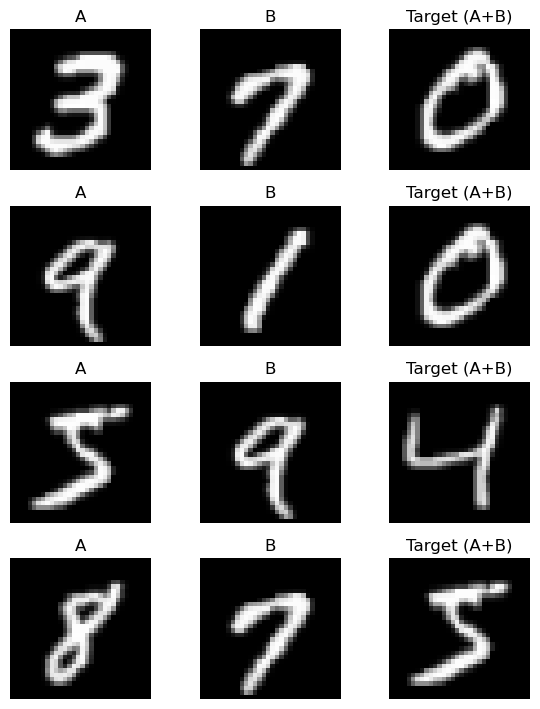

In [4]:
# Dataset builds pairs (a, b) and target = (a+b) % p using MNIST images (resized to 32x32)
batch_size = 16
p = 10  # use base-10 digits
ds_val = MNISTModularArithmeticDataset(p=p, split='val', train_fraction=0.7, num_images=1)
dl_val = DataLoader(ds_val, batch_size=batch_size, shuffle=True, drop_last=False)

# Fetch one batch
x_tgt_gt, x_src, y_label = next(iter(dl_val))
# x_tgt_gt: (B, 1, 32, 32) ground-truth digit image representing (a + b) % p
# x_src:    (B, 2, 32, 32) two input digit images stacked along channel dimension
# y_label:  (B,) the numeric label for the target digit
x_tgt_gt, x_src, y_label = x_tgt_gt.to(device), x_src.to(device), y_label.to(device)

# Visualize a few examples
def show_triplet(x_src, x_tgt_gt, n=4):
    n = min(n, x_src.size(0))
    fig, axes = plt.subplots(n, 3, figsize=(6, 1.8*n))
    for i in range(n):
        a = x_src[i, 0].detach().cpu().squeeze().numpy()
        b = x_src[i, 1].detach().cpu().squeeze().numpy()
        tgt = x_tgt_gt[i, 0].detach().cpu().squeeze().numpy()
        for col, img, title in [(0, a, 'A'), (1, b, 'B'), (2, tgt, 'Target (A+B)')]:
            ax = axes[i, col] if n>1 else axes[col]
            ax.imshow(img, cmap='gray', vmin=-1, vmax=1)
            ax.set_title(title); ax.axis('off')
    plt.tight_layout()

show_triplet(x_src, x_tgt_gt, n=4)


In [5]:
# for lid, block in enumerate(model.layers):
#     print(f"Layer {lid}: {block}")

Generated batch shape: torch.Size([16, 1, 32, 32])


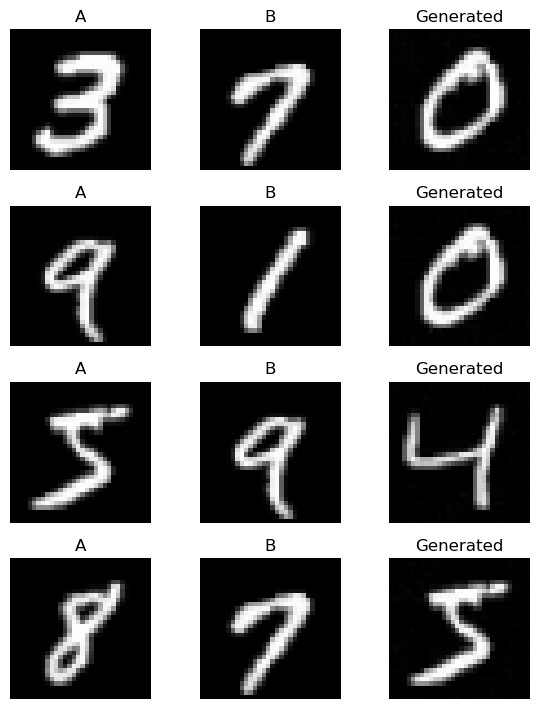

In [6]:
# Use the same RF wrapper as in training to do simple Euler sampling
rf = RF(model)
sample_steps = 1

with torch.no_grad():
    # Start from Gaussian noise for the target channel
    z0 = torch.randn_like(x_tgt_gt)
    imgs_over_time = rf.sample(z0, cond=x_src, sample_steps=sample_steps)

gen = imgs_over_time[-1].detach()
print("Generated batch shape:", gen.shape)

# Visualize generated results next to (A, B)
def show_src_and_gen(x_src, gen, n=4):
    n = min(n, x_src.size(0))
    fig, axes = plt.subplots(n, 3, figsize=(6, 1.8*n))
    for i in range(n):
        a = x_src[i, 0].detach().cpu().squeeze().numpy()
        b = x_src[i, 1].detach().cpu().squeeze().numpy()
        g = gen[i, 0].detach().cpu().squeeze().numpy()
        # g = vc[i, 0].detach().cpu().squeeze().numpy()
        for col, img, title in [(0, a, 'A'), (1, b, 'B'), (2, g, 'Generated')]: 
            ax = axes[i, col] if n>1 else axes[col]
            ax.imshow(img, cmap='gray', vmin=-1, vmax=1)
            ax.set_title(title); ax.axis('off')
    plt.tight_layout()

show_src_and_gen(x_src, gen, n=4)

In [7]:
if any(p.requires_grad for p in clf.parameters()) or hasattr(clf, 'fc'):
    try:
        with torch.no_grad():
            preds = clf(gen).argmax(dim=1)
        print("Predictions:", preds[:8].tolist(), "; GT:", y_label[:8].tolist())
    except Exception as e:
        print("Classifier not available or failed:", e)
else:
    print("Classifier weights not loaded; skipping numeric sanity check.")


Predictions: [0, 0, 4, 5, 1, 1, 7, 7] ; GT: [0, 0, 4, 5, 1, 1, 7, 7]


In [8]:
# # We'll attach hooks on each TransformerBlock to capture several tensors:
# # - attention input (post-norm) and output
# # - MLP input (post-norm) and output

# from collections import defaultdict
# act = defaultdict(list)

# def make_block_hooks(layer_id, block):
#     # attention input (post-norm) — forward_pre_hook: (module, input)
#     def attn_in_hook(mod, inp):
#         # inp is a tuple; want inp[0] = post-norm tensor [B, T, D]
#         x = inp[0].detach()
#         act[f'layer{layer_id}_attn_in'].append(x)

#     # attention output — forward_hook: (module, input, output)
#     def attn_out_hook(mod, inp, out):
#         # out may be tensor or tuple; grab first if tuple
#         x = (out[0] if isinstance(out, tuple) else out).detach()
#         act[f'layer{layer_id}_attn_out'].append(x)

#     # ffn input (post-norm)
#     def ffn_in_hook(mod, inp):
#         x = inp[0].detach()
#         act[f'layer{layer_id}_ffn_in'].append(x)

#     # ffn output
#     def ffn_out_hook(mod, inp, out):
#         x = (out[0] if isinstance(out, tuple) else out).detach()
#         act[f'layer{layer_id}_ffn_out'].append(x)

#     h1 = block.attention.register_forward_pre_hook(attn_in_hook)
#     h2 = block.attention.register_forward_hook(attn_out_hook)
#     h3 = block.feed_forward.register_forward_pre_hook(ffn_in_hook)
#     h4 = block.feed_forward.register_forward_hook(ffn_out_hook)
#     return [h1, h2, h3, h4]

# # Register hooks on all blocks
# hooks = []
# for lid, block in enumerate(model.layers):
#     hooks.extend(make_block_hooks(lid, block))

# # Single forward pass to populate activations
# with torch.no_grad():
#     x = gen[:1]          # (1,1,32,32)
#     y = x_src[:1]        # (1,2,32,32)
#     t = torch.tensor([0.5], device=device)
#     _ = model(x, t, y)

# # Detach hooks
# for h in hooks:
#     h.remove()

# sorted(list(act.keys()))[:8], len(act)


In [9]:
from collections import defaultdict
act = defaultdict(list)

def make_block_hooks(layer_id, block):
    layer_key = f'layer{layer_id}'
    cache = {}  # transient per-forward cache for this layer

    # --- Residual pre-attention: x0 ---
    def attn_norm_pre(mod, inp):
        # attention_norm receives x0 and returns LN(x0)
        x0 = inp[0].detach()
        cache['x0'] = x0
        act[f'{layer_key}_res_pre_attn'].append(x0)

    # --- Attention output zA, then residual post-attn: x1 = x0 + zA ---
    def attn_out(mod, inp, out):
        zA = (out[0] if isinstance(out, tuple) else out).detach()
        x0 = cache.get('x0')
        if x0 is not None:
            x1 = (x0 + zA).detach()
            cache['x1'] = x1
            act[f'{layer_key}_res_post_attn'].append(x1)
        act[f'{layer_key}_attn_out'].append(zA)  # keep your original too

    # --- Residual pre-ffn: x1 (should equal cached x1) ---
    def ffn_norm_pre(mod, inp):
        x1_check = inp[0].detach()
        cache['x1_check'] = x1_check
        act[f'{layer_key}_res_pre_ffn'].append(x1_check)

    # --- FFN output zF, then residual post-ffn: x2 = x1 + zF ---
    def ffn_out(mod, inp, out):
        zF = (out[0] if isinstance(out, tuple) else out).detach()
        x1 = cache.get('x1')  # computed from x0 + zA
        if x1 is None:
            # fallback to x1_check from ffn_norm pre-hook
            x1 = cache.get('x1_check')
        if x1 is not None:
            x2 = (x1 + zF).detach()
            act[f'{layer_key}_res_post_ffn'].append(x2)
        act[f'{layer_key}_ffn_out'].append(zF)  # keep your original too

    # --- (Optional) block-level in/out for sanity ---
    def block_inout(mod, inp, out):
        # inp[0] is block input x0; out is block output x2
        x0_block = inp[0].detach()
        x2_block = (out[0] if isinstance(out, tuple) else out).detach()
        act[f'{layer_key}_block_in'].append(x0_block)
        act[f'{layer_key}_block_out'].append(x2_block)

    h = []
    h.append(block.attention_norm.register_forward_pre_hook(attn_norm_pre))
    h.append(block.attention.register_forward_hook(attn_out))
    h.append(block.ffn_norm.register_forward_pre_hook(ffn_norm_pre))
    h.append(block.feed_forward.register_forward_hook(ffn_out))
    h.append(block.register_forward_hook(block_inout))  # optional but useful
    return h

# Register hooks on all blocks
hooks = []
for lid, block in enumerate(model.layers):
    hooks.extend(make_block_hooks(lid, block))

# Single forward pass to populate activations
with torch.no_grad():
    x = gen[:1]          # (1,1,32,32)
    y = x_src[:1]        # (1,2,32,32)
    t = torch.tensor([0.5], device=device)
    _ = model(x, t, y)

# Detach hooks
for h in hooks:
    h.remove()

# Example: confirm equality relations
# res_pre_attn == block_in; res_post_ffn == block_out (modulo FP noise)
for lid in range(len(model.layers)):
    a = act[f'layer{lid}_res_pre_attn'][-1]
    b = act[f'layer{lid}_block_in'][-1]
    print(f'Layer {lid} pre-attn ~ block_in  max|diff| = {(a-b).abs().max().item():.3e}')
    a = act[f'layer{lid}_res_post_ffn'][-1]
    b = act[f'layer{lid}_block_out'][-1]
    print(f'Layer {lid} post-ffn ~ block_out max|diff| = {(a-b).abs().max().item():.3e}')


Layer 0 pre-attn ~ block_in  max|diff| = 0.000e+00
Layer 0 post-ffn ~ block_out max|diff| = 2.418e+01
Layer 1 pre-attn ~ block_in  max|diff| = 0.000e+00
Layer 1 post-ffn ~ block_out max|diff| = 2.349e+01
Layer 2 pre-attn ~ block_in  max|diff| = 0.000e+00
Layer 2 post-ffn ~ block_out max|diff| = 1.328e+01
Layer 3 pre-attn ~ block_in  max|diff| = 0.000e+00
Layer 3 post-ffn ~ block_out max|diff| = 1.776e+01
Layer 4 pre-attn ~ block_in  max|diff| = 0.000e+00
Layer 4 post-ffn ~ block_out max|diff| = 1.981e+01
Layer 5 pre-attn ~ block_in  max|diff| = 0.000e+00
Layer 5 post-ffn ~ block_out max|diff| = 2.256e+01
Layer 6 pre-attn ~ block_in  max|diff| = 0.000e+00
Layer 6 post-ffn ~ block_out max|diff| = 4.157e+01
Layer 7 pre-attn ~ block_in  max|diff| = 0.000e+00
Layer 7 post-ffn ~ block_out max|diff| = 3.873e+01
Layer 8 pre-attn ~ block_in  max|diff| = 0.000e+00
Layer 8 post-ffn ~ block_out max|diff| = 6.788e+01
Layer 9 pre-attn ~ block_in  max|diff| = 0.000e+00
Layer 9 post-ffn ~ block_out ma

In [10]:
act.keys()

dict_keys(['layer0_res_pre_attn', 'layer0_res_post_attn', 'layer0_attn_out', 'layer0_res_pre_ffn', 'layer0_res_post_ffn', 'layer0_ffn_out', 'layer0_block_in', 'layer0_block_out', 'layer1_res_pre_attn', 'layer1_res_post_attn', 'layer1_attn_out', 'layer1_res_pre_ffn', 'layer1_res_post_ffn', 'layer1_ffn_out', 'layer1_block_in', 'layer1_block_out', 'layer2_res_pre_attn', 'layer2_res_post_attn', 'layer2_attn_out', 'layer2_res_pre_ffn', 'layer2_res_post_ffn', 'layer2_ffn_out', 'layer2_block_in', 'layer2_block_out', 'layer3_res_pre_attn', 'layer3_res_post_attn', 'layer3_attn_out', 'layer3_res_pre_ffn', 'layer3_res_post_ffn', 'layer3_ffn_out', 'layer3_block_in', 'layer3_block_out', 'layer4_res_pre_attn', 'layer4_res_post_attn', 'layer4_attn_out', 'layer4_res_pre_ffn', 'layer4_res_post_ffn', 'layer4_ffn_out', 'layer4_block_in', 'layer4_block_out', 'layer5_res_pre_attn', 'layer5_res_post_attn', 'layer5_attn_out', 'layer5_res_pre_ffn', 'layer5_res_post_ffn', 'layer5_ffn_out', 'layer5_block_in', '

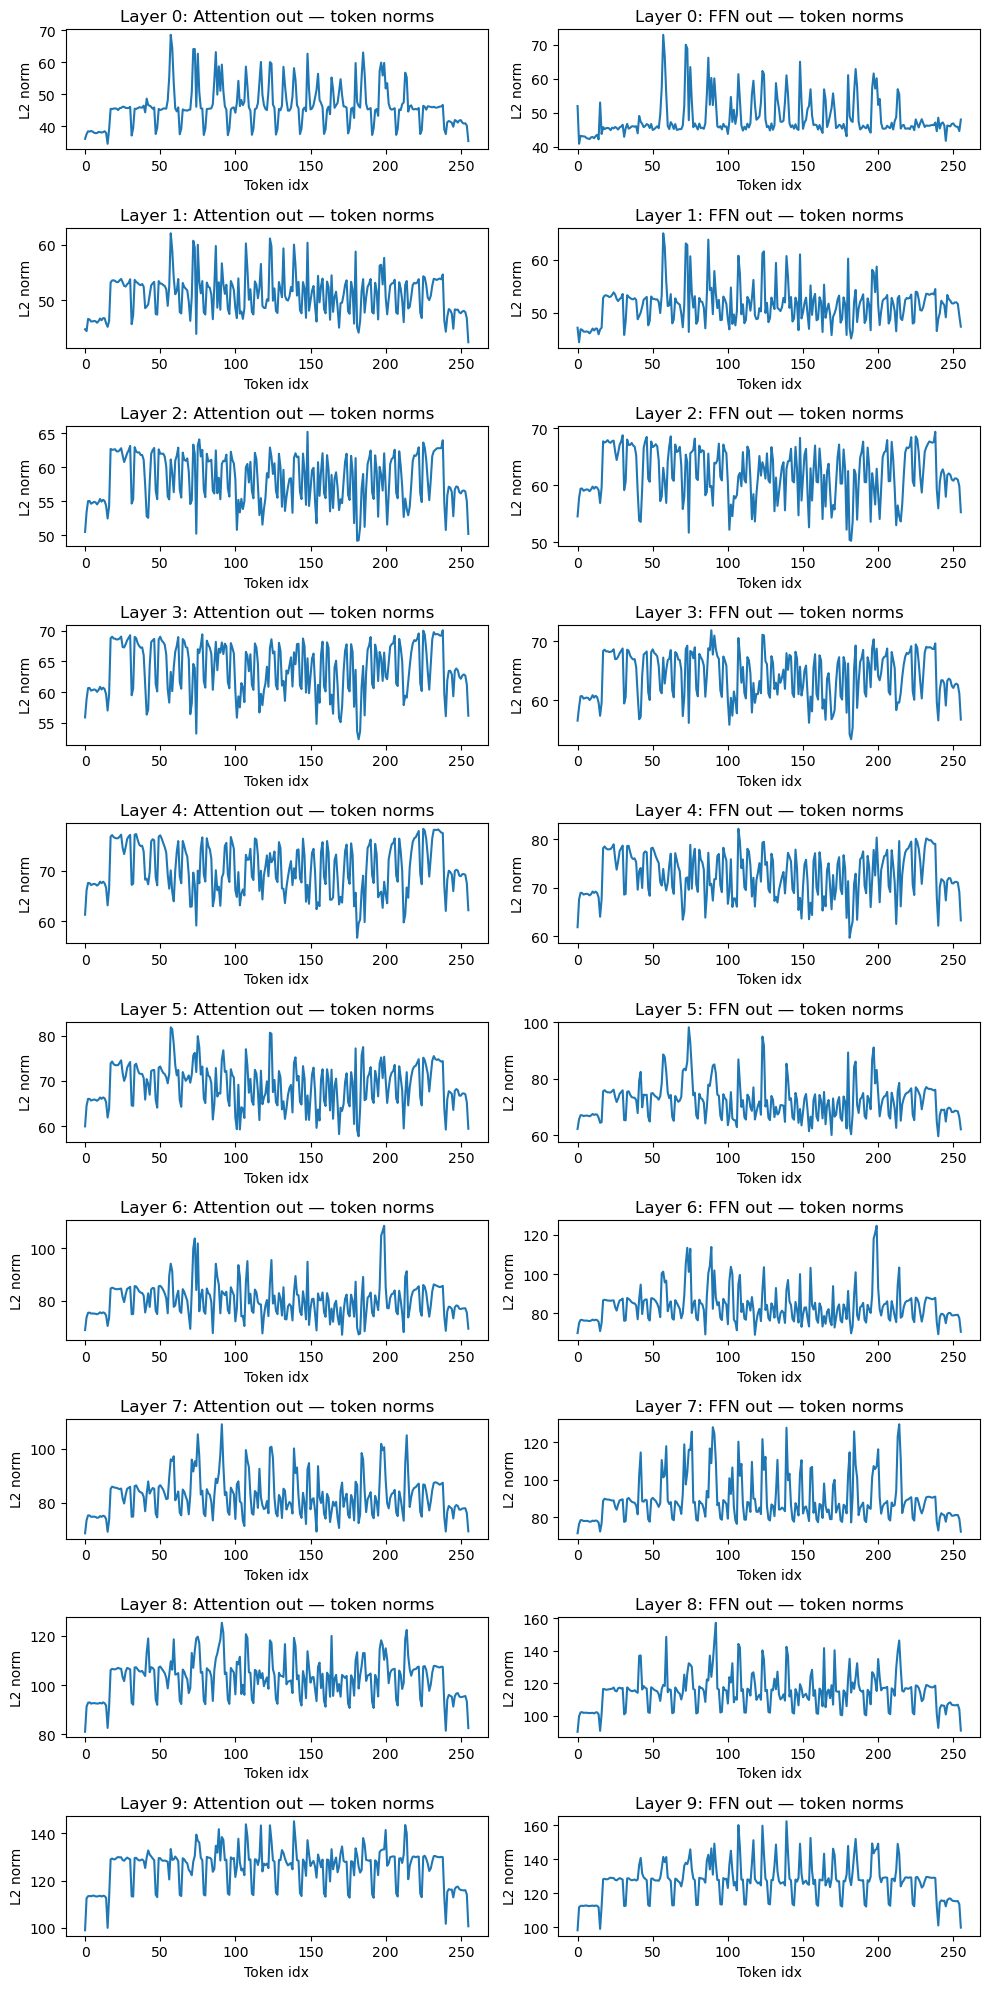

In [11]:
# Helper: compute token-wise L2 norms per layer output and plot
def token_norms(x):  # x: [B, T, D]
    # average over batch -> [T]
    with torch.no_grad():
        n = torch.linalg.vector_norm(x, dim=-1).mean(dim=0).cpu().numpy()
    return n

layer_count = len(model.layers)
fig, axes = plt.subplots(layer_count, 2, figsize=(10, 2.0*layer_count))

for lid in range(layer_count):
    # Take the last captured entry per layer (from our one forward pass)
    # a_in = act[f'layer{lid}_attn_in'][-1]
    a_out = act[f'layer{lid}_res_post_attn'][-1]
    # f_in = act[f'layer{lid}_ffn_in'][-1]
    f_out = act[f'layer{lid}_res_post_ffn'][-1]

    # Plot token norms for attention out and ffn out
    tn_attn = token_norms(a_out)
    tn_ffn  = token_norms(f_out)

    ax0, ax1 = axes[lid]
    ax0.plot(tn_attn); ax0.set_title(f'Layer {lid}: Attention out — token norms')
    ax0.set_xlabel('Token idx'); ax0.set_ylabel('L2 norm')

    ax1.plot(tn_ffn); ax1.set_title(f'Layer {lid}: FFN out — token norms')
    ax1.set_xlabel('Token idx'); ax1.set_ylabel('L2 norm')

plt.tight_layout()
plt.show()


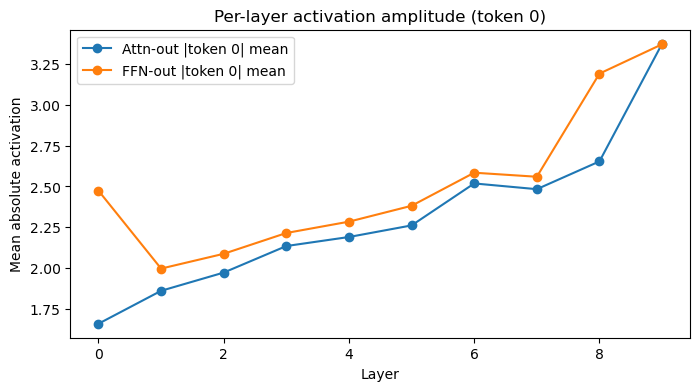

In [12]:
# Choose a particular token index (e.g. 0) and track mean activation magnitude across layers
token_idx = 0
attn_means = []
ffn_means = []
for lid in range(len(model.layers)):
    a_out = act[f'layer{lid}_res_post_attn'][-1]  # [B,T,D]
    f_out = act[f'layer{lid}_res_post_ffn'][-1]
    attn_means.append(a_out[0, token_idx].abs().mean().item())
    ffn_means.append(f_out[0, token_idx].abs().mean().item())

plt.figure(figsize=(8,4))
plt.plot(attn_means, marker='o', label='Attn-out |token 0| mean')
plt.plot(ffn_means, marker='o', label='FFN-out |token 0| mean')
plt.xlabel('Layer'); plt.ylabel('Mean absolute activation'); plt.legend(); plt.title('Per-layer activation amplitude (token 0)')
plt.show()



### Going deeper (optional)

If you want **attention weights** per head, you'd need to modify `Attention.forward` to return them (or to store them on the module during the forward pass). The current implementation uses `torch.nn.functional.scaled_dot_product_attention`, which does not expose the attention matrix by default. Two approaches:

1. **Re-implement attention scores** with `softmax(q @ k^T / sqrt(d))` and capture the probabilities before multiplying by `v`.
2. **Monkey-patch** the `Attention.forward` method temporarily to compute and return both the attention output and the attention probabilities.

For quick diagnostics, the token-norm profiles above are often enough to spot saturation, collapse, or dead tokens.


In [13]:
import torch
from collections import defaultdict
from typing import List, Dict, Literal, Optional

Reduction = Literal["none", "token_mean", "feature_mean"]

class MultiPassActivationCollector:
    def __init__(
        self,
        model,
        which: List[str] = [
            "attn_in", "attn_out", "ffn_in", "ffn_out",
            "res_pre_attn", "res_post_attn", "res_pre_ffn", "res_post_ffn",
            # "block_in", "block_out",  # optional
        ],
        reduction: Reduction = "none",
        device: Optional[torch.device] = None,
    ):
        """
        which:
          any subset of:
            - "attn_in"       : post-norm input to Attention (LN(x))
            - "attn_out"      : Attention output z_A
            - "ffn_in"        : post-norm input to FFN (LN(x))
            - "ffn_out"       : FFN output z_F
            - "res_pre_attn"  : residual entering block, x0
            - "res_post_attn" : residual after attention, x1 = x0 + z_A
            - "res_pre_ffn"   : residual before FFN, x1
            - "res_post_ffn"  : residual after FFN, x2 = x1 + z_F
            - "block_in"      : block input (same as res_pre_attn)
            - "block_out"     : block output (same as res_post_ffn)

        reduction:
          - "none": store full [B, T, D]
          - "token_mean": reduce over tokens -> [B, D]
          - "feature_mean": reduce over feature dim -> [B, T]
        """
        self.model = model
        self.which = set(which)
        self.reduction = reduction
        self.device = device or next(model.parameters()).device

        self._hooks = []
        self._active_sink = None  # will point to a dict during a forward pass

        # Attach hooks to all blocks once
        for lid, block in enumerate(model.layers):
            layer_key = f"layer{lid}"
            cache = {}  # per-layer, per-forward cache

            # --------- Residual stream hooks ----------

            # res_pre_attn: x0 = input to attention_norm
            if "res_pre_attn" in self.which or "res_post_attn" in self.which \
               or "res_pre_ffn" in self.which or "res_post_ffn" in self.which:

                def _attn_norm_pre(mod, inp, _lid=lid, _cache=cache, _layer_key=layer_key):
                    # attention_norm receives x0 and returns LN(x0)
                    x0 = inp[0].detach()
                    _cache["x0"] = x0
                    if "res_pre_attn" in self.which:
                        self._record(f"{_layer_key}_res_pre_attn", x0)

                self._hooks.append(block.attention_norm.register_forward_pre_hook(_attn_norm_pre))

            # res_post_attn + attn_out
            if "attn_out" in self.which or "res_post_attn" in self.which \
               or "res_pre_ffn" in self.which or "res_post_ffn" in self.which:

                def _attn_out(mod, inp, out, _lid=lid, _cache=cache, _layer_key=layer_key):
                    zA = (out[0] if isinstance(out, tuple) else out).detach()

                    if "attn_out" in self.which:
                        self._record(f"{_layer_key}_attn_out", zA)

                    x0 = _cache.get("x0")
                    if x0 is not None:
                        x1 = (x0 + zA).detach()
                        _cache["x1"] = x1
                        if "res_post_attn" in self.which:
                            self._record(f"{_layer_key}_res_post_attn", x1)

                self._hooks.append(block.attention.register_forward_hook(_attn_out))

            # res_pre_ffn: x1 (input to ffn_norm)
            if "res_pre_ffn" in self.which or "res_post_ffn" in self.which:

                def _ffn_norm_pre(mod, inp, _lid=lid, _cache=cache, _layer_key=layer_key):
                    x1_check = inp[0].detach()
                    _cache["x1_check"] = x1_check
                    if "res_pre_ffn" in self.which:
                        self._record(f"{_layer_key}_res_pre_ffn", x1_check)

                self._hooks.append(block.ffn_norm.register_forward_pre_hook(_ffn_norm_pre))

            # res_post_ffn + ffn_out
            if "ffn_out" in self.which or "res_post_ffn" in self.which:

                def _ffn_out(mod, inp, out, _lid=lid, _cache=cache, _layer_key=layer_key):
                    zF = (out[0] if isinstance(out, tuple) else out).detach()

                    if "ffn_out" in self.which:
                        self._record(f"{_layer_key}_ffn_out", zF)

                    x1 = _cache.get("x1")
                    if x1 is None:
                        x1 = _cache.get("x1_check")
                    if x1 is not None and "res_post_ffn" in self.which:
                        x2 = (x1 + zF).detach()
                        self._record(f"{_layer_key}_res_post_ffn", x2)

                self._hooks.append(block.feed_forward.register_forward_hook(_ffn_out))

            # --------- (Optional) original attn_in / ffn_in (post-norm inputs) ----------

            if "attn_in" in self.which:
                def _attn_in_hook(mod, inp, _lid=lid, _layer_key=layer_key):
                    x = inp[0].detach()
                    self._record(f"{_layer_key}_attn_in", x)
                self._hooks.append(block.attention.register_forward_pre_hook(_attn_in_hook))

            if "ffn_in" in self.which:
                def _ffn_in_hook(mod, inp, _lid=lid, _layer_key=layer_key):
                    x = inp[0].detach()
                    self._record(f"{_layer_key}_ffn_in", x)
                self._hooks.append(block.feed_forward.register_forward_pre_hook(_ffn_in_hook))

            # --------- (Optional) block-level in/out ----------

            if "block_in" in self.which or "block_out" in self.which:
                def _block_inout(mod, inp, out, _lid=lid, _layer_key=layer_key):
                    x_in = inp[0].detach()
                    x_out = (out[0] if isinstance(out, tuple) else out).detach()
                    if "block_in" in self.which:
                        self._record(f"{_layer_key}_block_in", x_in)
                    if "block_out" in self.which:
                        self._record(f"{_layer_key}_block_out", x_out)
                self._hooks.append(block.register_forward_hook(_block_inout))

    def _reduce(self, x: torch.Tensor) -> torch.Tensor:
        # x shape is [B, T, D]
        if self.reduction == "none":
            return x
        elif self.reduction == "token_mean":
            return x.mean(dim=1)     # [B, D]
        elif self.reduction == "feature_mean":
            return x.mean(dim=-1)    # [B, T]
        else:
            raise ValueError(f"Unknown reduction: {self.reduction}")

    def _record(self, key: str, x: torch.Tensor):
        if self._active_sink is None:
            return
        # Ensure tensor is [B, T, D] before reduction:
        if x.dim() == 3:
            pass
        elif x.dim() == 2:
            # Upgrade [B, D] to [B, 1, D] so reductions still work
            x = x.unsqueeze(1)
        else:
            raise RuntimeError(f"Unexpected activation shape {tuple(x.shape)} for key={key}")

        x = self._reduce(x)
        self._active_sink.setdefault(key, []).append(x.cpu())

    def collect_over_loader(
        self,
        data_loader,
        *,
        max_batches: Optional[int] = None,
        items_per_batch: Optional[int] = None,
        time_strategy: Literal["fixed", "random"] = "fixed",
        fixed_t: float = 0.5,
        save_path: str = "activations.pt",
        show_progress: bool = True,
    ) -> Dict[str, torch.Tensor]:
        """
        data_loader should yield (x_tgt_gt, x_src, y_label)
        We forward: model(zt, t, x_src), where zt is noisy mixture of x_tgt_gt.

        max_batches: limit number of batches processed (None = all)
        items_per_batch: optionally subsample first K items from each batch
        time_strategy:
          - "fixed": use the same t for all samples (fixed_t)
          - "random": t ~ Uniform(0,1) per sample
        """
        from collections import defaultdict
        agg: Dict[str, List[torch.Tensor]] = defaultdict(list)
        processed_batches = 0

        if show_progress:
            try:
                from tqdm import tqdm
                iterator = tqdm(data_loader, total=max_batches or len(data_loader))
            except Exception:
                iterator = data_loader
        else:
            iterator = data_loader

        self.model.eval()
        with torch.no_grad():
            for batch in iterator:
                if max_batches is not None and processed_batches >= max_batches:
                    break

                x_tgt_gt, x_src, _ = batch
                if items_per_batch is not None:
                    x_tgt_gt = x_tgt_gt[:items_per_batch]
                    x_src    = x_src[:items_per_batch]

                x_tgt_gt = x_tgt_gt.to(self.device)
                x_src    = x_src.to(self.device)

                B = x_tgt_gt.size(0)
                if time_strategy == "fixed":
                    t = torch.full((B,), float(fixed_t), device=self.device)
                else:  # random
                    t = torch.rand(B, device=self.device)

                # Diffusion-style noisy input at time t
                texp = t.view([B, *([1] * len(x_tgt_gt.shape[1:]))])
                z1 = torch.randn_like(x_tgt_gt)
                zt = (1 - texp) * x_tgt_gt + texp * z1
                zt = zt.to(self.device)

                # One forward pass; hooks will populate self._active_sink
                self._active_sink = {}
                _ = self.model(zt, t, x_src)
                current = self._active_sink
                self._active_sink = None

                # Merge current into agg
                for k, tensors in current.items():
                    cat = torch.cat(tensors, dim=0)
                    agg[k].append(cat)

                processed_batches += 1

        # Final concat across batches -> big arrays
        big: Dict[str, torch.Tensor] = {}
        for k, tensor_list in agg.items():
            big[k] = torch.cat(tensor_list, dim=0)  # stack batches along 0

        # Save to disk for later use
        torch.save(
            {
                "which": list(self.which),
                "reduction": self.reduction,
                "keys": sorted(big.keys()),
                "tensors": {k: v for k, v in big.items()},
            },
            save_path,
        )
        print(f"Saved activations to: {save_path}")
        for k in sorted(big.keys()):
            print(f"{k}: {tuple(big[k].shape)}")
        return big

    def close(self):
        for h in self._hooks:
            h.remove()
        self._hooks = []

# ---- Example usage ---------------------------------------------------------

# Create a validation loader (reuse from earlier cell if you already made one)
ds_val  = MNISTModularArithmeticDataset(p=10, split='val', train_fraction=0.7, num_images=1)
dl_val  = DataLoader(ds_val, batch_size=100, shuffle=False, drop_last=False)

# Create loader for entire dataset
ds_full  = MNISTModularArithmeticDataset(p=10, split='train', train_fraction=1.0, num_images=1)
dl_full  = DataLoader(ds_full, batch_size=100, shuffle=False, drop_last=False)

collector = MultiPassActivationCollector(
    model,
    which=["res_post_attn",
        "res_post_ffn"],   # capture what you need
    reduction="none",                # "none" | "token_mean" | "feature_mean"
    device=device,
)

# Collect over a handful of batches to keep memory reasonable on first run.
big = collector.collect_over_loader(
    dl_full,
    max_batches=None,            # increase if you want more data
    items_per_batch=None,      # or an int (e.g., 16) to subsample within batch
    time_strategy="fixed",    # "fixed" or "random"
    fixed_t=1.00,
    save_path="activations.pt",
    show_progress=True,
)

# Example: access the big arrays
# big["layer0_attn_out"] -> shape depends on reduction:
#   - "none": [N, T, D] (N = total items across batches)
#   - "token_mean": [N, D]
#   - "feature_mean": [N, T]

# When done with collection (e.g., before reloading a new model), detach hooks:
# collector.close()


100%|██████████| 1/1 [00:00<00:00,  2.97it/s]


Saved activations to: activations.pt
layer0_res_post_attn: (100, 256, 256)
layer0_res_post_ffn: (100, 256, 256)
layer1_res_post_attn: (100, 256, 256)
layer1_res_post_ffn: (100, 256, 256)
layer2_res_post_attn: (100, 256, 256)
layer2_res_post_ffn: (100, 256, 256)
layer3_res_post_attn: (100, 256, 256)
layer3_res_post_ffn: (100, 256, 256)
layer4_res_post_attn: (100, 256, 256)
layer4_res_post_ffn: (100, 256, 256)
layer5_res_post_attn: (100, 256, 256)
layer5_res_post_ffn: (100, 256, 256)
layer6_res_post_attn: (100, 256, 256)
layer6_res_post_ffn: (100, 256, 256)
layer7_res_post_attn: (100, 256, 256)
layer7_res_post_ffn: (100, 256, 256)
layer8_res_post_attn: (100, 256, 256)
layer8_res_post_ffn: (100, 256, 256)
layer9_res_post_attn: (100, 256, 256)
layer9_res_post_ffn: (100, 256, 256)


In [14]:
# Apply MNIST classifier to input images
clf = MNISTClassifier().to(device)
clf_ckpt = 'weights/mnist_classifier_weights.pth'
clf.load_state_dict(torch.load(clf_ckpt, map_location=device))

clf.eval()

# Build a loader over the *validation dataset order* so outputs align 1:1 with ds_val indices.
val_loader = DataLoader(ds_full, batch_size=64, shuffle=False, drop_last=False)
# val_loader = dl_full

all_A_pred = []
all_B_pred = []
all_A_conf = []
all_B_conf = []
all_sum_label = []

# Figure out classifier's expected spatial size (fallback to 28x28)
try:
    # If your classifier exposes something like clf.input_size, use it; otherwise default to 28.
    target_h = getattr(clf, "input_h", 28)
    target_w = getattr(clf, "input_w", 28)
except Exception:
    target_h, target_w = 28, 28

with torch.no_grad():
    for x_tgt_gt, x_src, y_label in val_loader:
        # x_src: [B, 2, H, W]; split channels
        A = x_src[:, 0:1].to(device)  # [B,1,H,W]
        B = x_src[:, 1:2].to(device)

        # Resize to classifier input (if needed)
        if A.shape[-2:] != (target_h, target_w):
            A = F.interpolate(A, size=(target_h, target_w), mode="bilinear", align_corners=False)
            B = F.interpolate(B, size=(target_h, target_w), mode="bilinear", align_corners=False)

        # Classifier forward → logits
        logits_A = clf(A)
        logits_B = clf(B)

        # Softmax for confidences & argmax for labels
        probs_A = logits_A.softmax(dim=1)
        probs_B = logits_B.softmax(dim=1)

        conf_A, pred_A = probs_A.max(dim=1)  # [B], [B]
        conf_B, pred_B = probs_B.max(dim=1)

        all_A_pred.append(pred_A.detach().cpu())
        all_B_pred.append(pred_B.detach().cpu())
        all_A_conf.append(conf_A.detach().cpu())
        all_B_conf.append(conf_B.detach().cpu())
        all_sum_label.append(y_label.detach().cpu())

# Concatenate across batches
A_pred = torch.cat(all_A_pred).numpy()         # shape [N]
B_pred = torch.cat(all_B_pred).numpy()         # shape [N]
A_conf = torch.cat(all_A_conf).numpy()         # shape [N] (max softmax prob)
B_conf = torch.cat(all_B_conf).numpy()         # shape [N]
sum_label = torch.cat(all_sum_label).numpy()   # shape [N] (ground-truth (A+B)%p)

# Quick sanity: does predicted (A+B)%p match the dataset sum?
p_mod = 10  # change if you used a different modulus p
sum_pred = (A_pred + B_pred) % p_mod
acc = (sum_pred == sum_label).mean()
print(f"Consistency check: predicted (A+B)%{p_mod} vs. target → accuracy = {acc:.3f}")

# (Optional) show a few rows
for i in range(min(10, len(A_pred))):
    print(f"idx {i:2d} | A={A_pred[i]} ({A_conf[i]:.2f})  B={B_pred[i]} ({B_conf[i]:.2f})  | target sum={sum_label[i]}  | pred sum={sum_pred[i]}")

Consistency check: predicted (A+B)%10 vs. target → accuracy = 1.000
idx  0 | A=8 (1.00)  B=3 (1.00)  | target sum=1  | pred sum=1
idx  1 | A=5 (1.00)  B=3 (1.00)  | target sum=8  | pred sum=8
idx  2 | A=7 (1.00)  B=0 (1.00)  | target sum=7  | pred sum=7
idx  3 | A=4 (1.00)  B=5 (1.00)  | target sum=9  | pred sum=9
idx  4 | A=4 (1.00)  B=4 (1.00)  | target sum=8  | pred sum=8
idx  5 | A=3 (1.00)  B=9 (1.00)  | target sum=2  | pred sum=2
idx  6 | A=2 (1.00)  B=2 (1.00)  | target sum=4  | pred sum=4
idx  7 | A=8 (1.00)  B=0 (1.00)  | target sum=8  | pred sum=8
idx  8 | A=1 (1.00)  B=0 (1.00)  | target sum=1  | pred sum=1
idx  9 | A=0 (1.00)  B=0 (1.00)  | target sum=0  | pred sum=0


In [15]:
# If A+B>=10
carry = ((A_pred + B_pred) >= p_mod).astype(np.int32)
carry

array([1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1,
       0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1,
       1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0], dtype=int32)

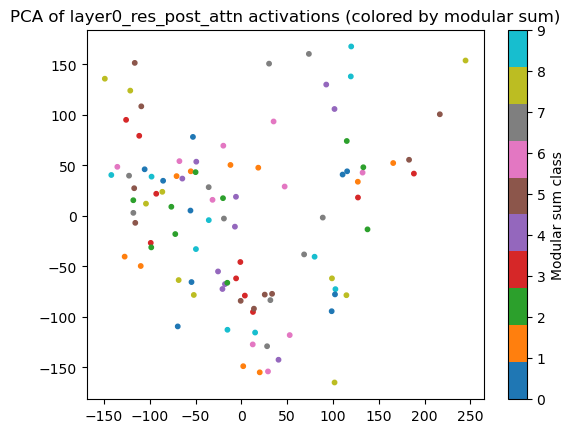

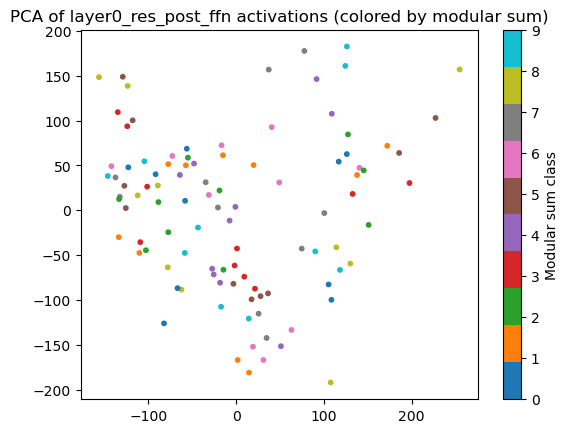

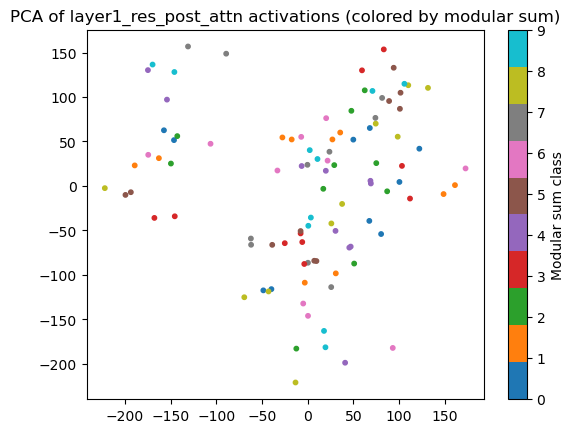

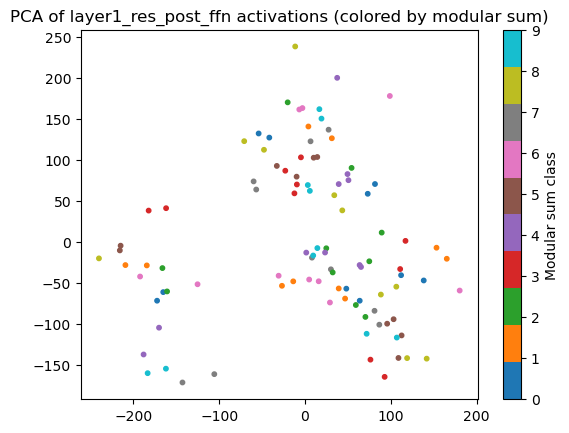

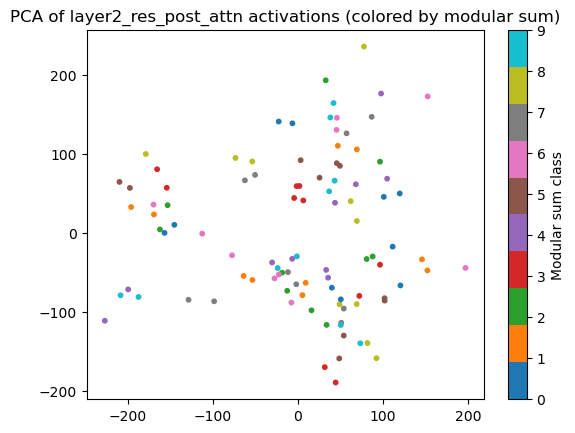

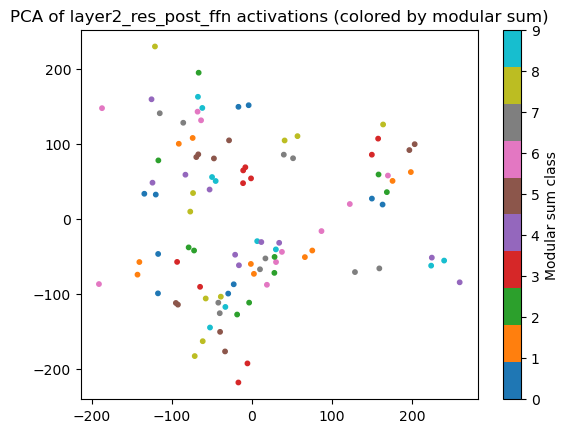

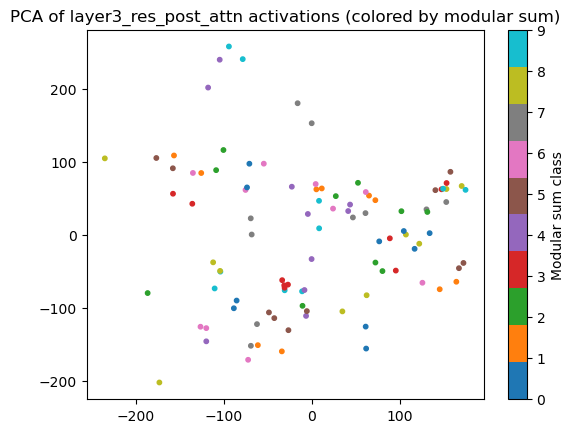

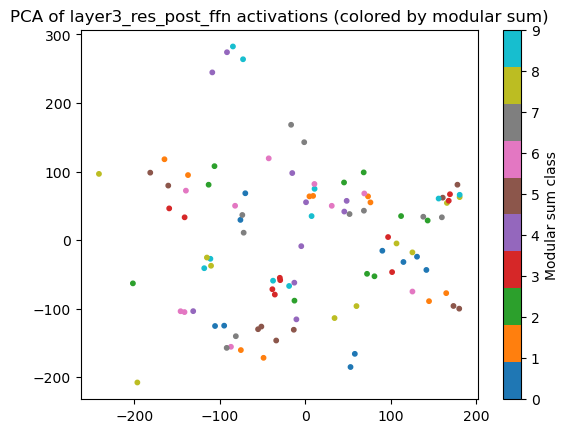

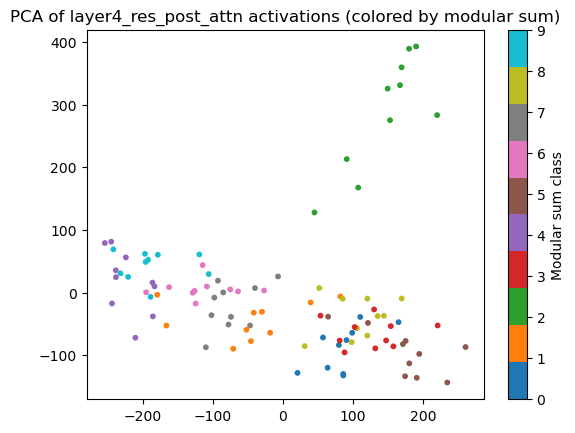

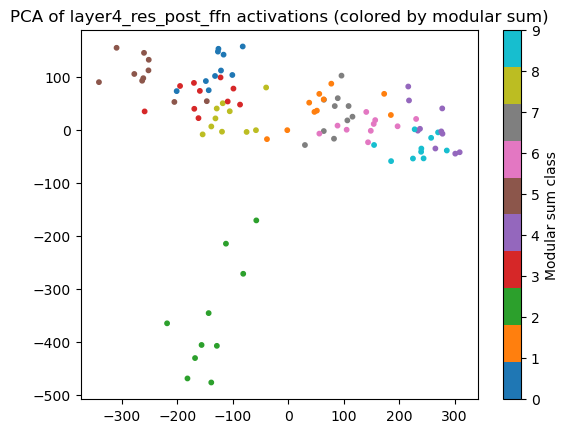

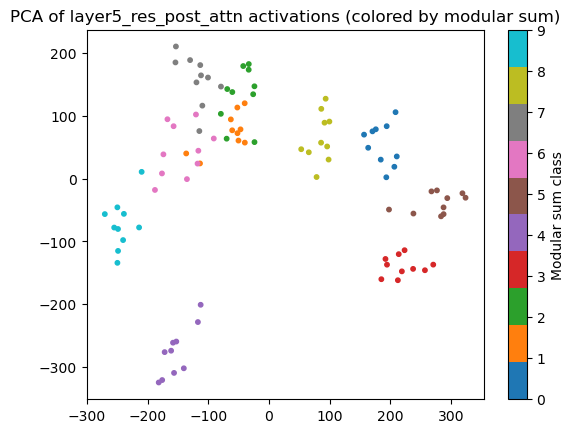

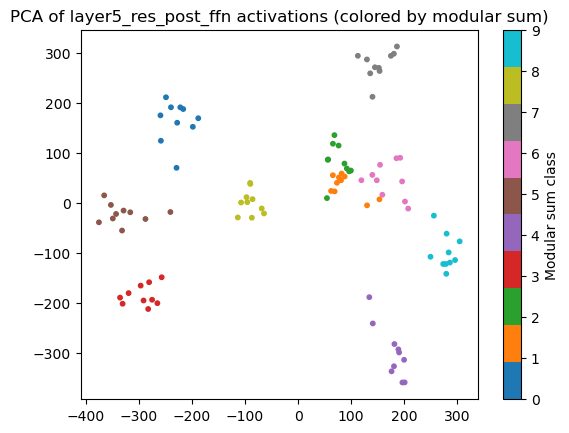

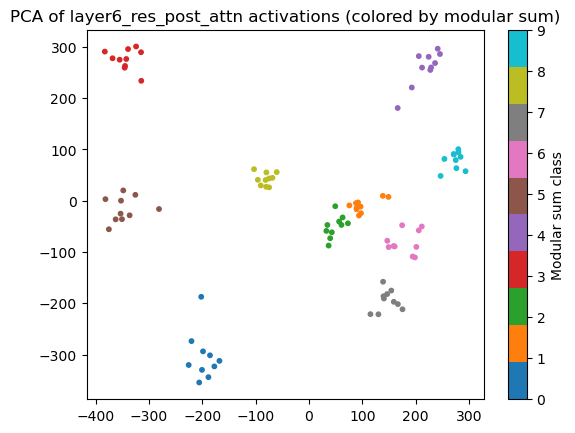

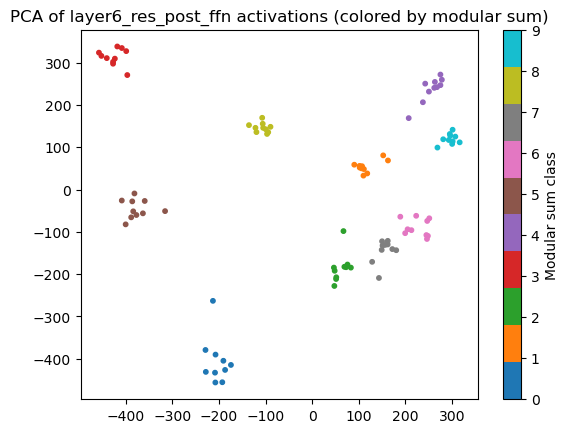

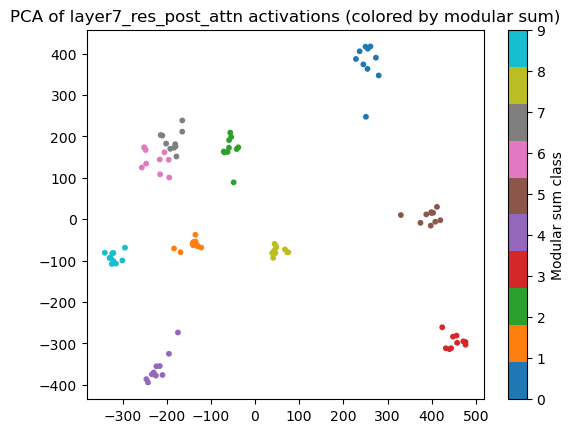

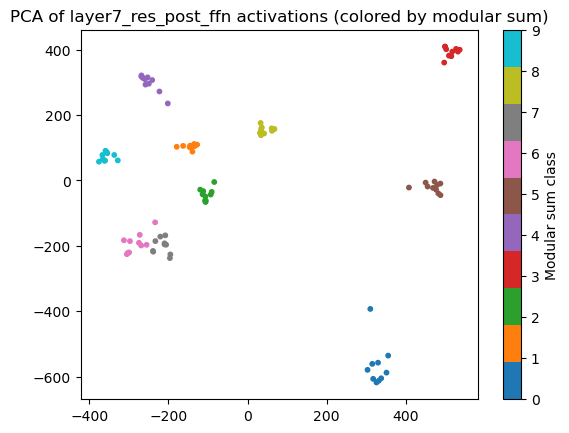

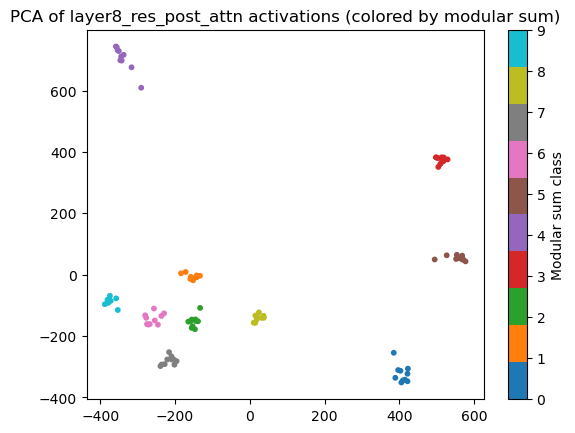

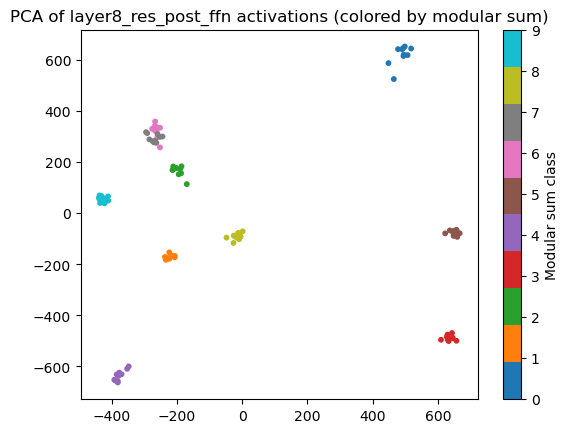

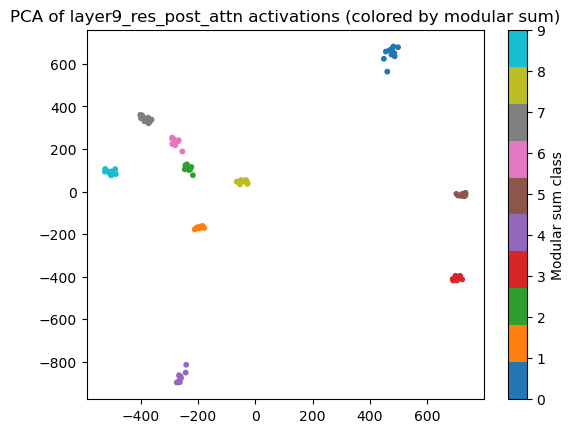

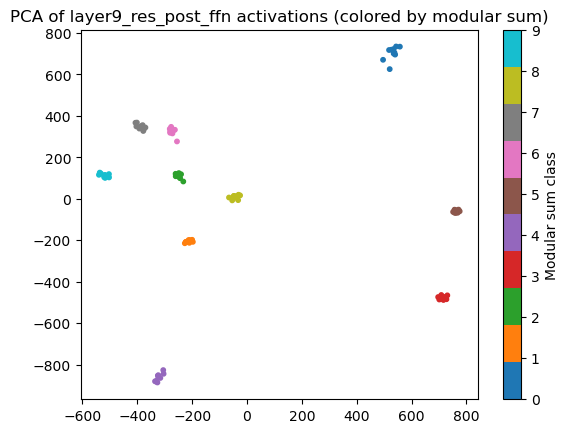

In [16]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

test = "layer8_ffn_out"

for test in big.keys():

    acts = big[test].reshape(len(big[test]), -1)
    # labels = y_label.cpu().numpy()
    # labels = np.array([y for _, _, y in ds_val])
    labels = np.array([y for _, _, y in ds_full])
    # labels = carry

    pc = PCA(4).fit_transform(acts)
    plt.scatter(pc[:,0], pc[:,1], c=labels, cmap='tab10', s=10)
    plt.title(f"PCA of {test} activations (colored by modular sum)")
    # Legend for 10 classes
    cbar = plt.colorbar(ticks=range(10))
    cbar.set_label('Modular sum class')
    plt.show()

In [17]:
# labels = np.array([y for y, _, _ in ds_full])
# labels

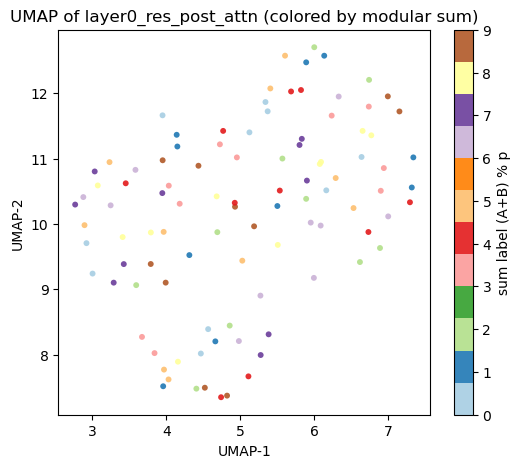

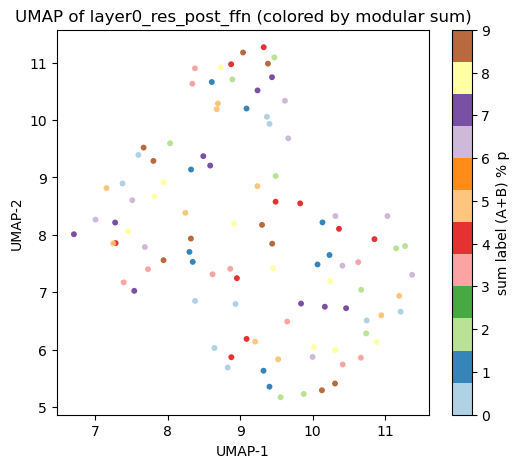

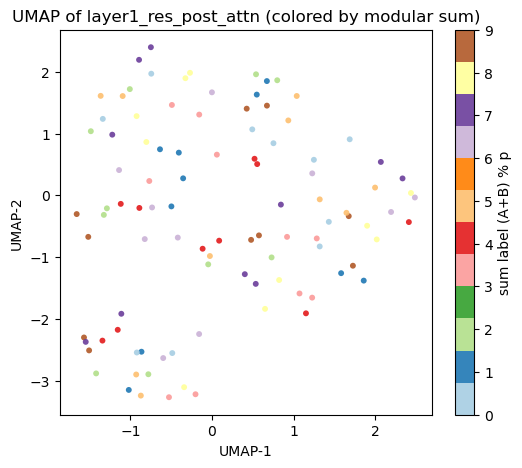

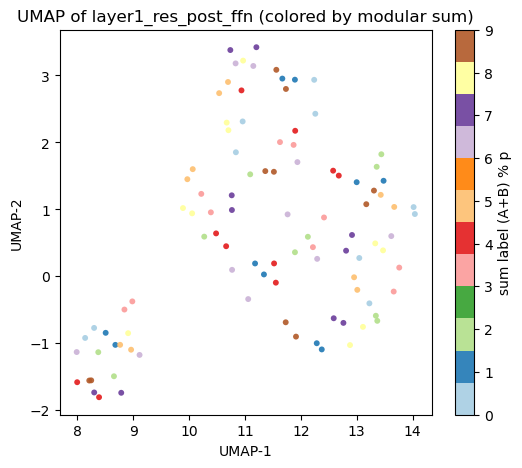

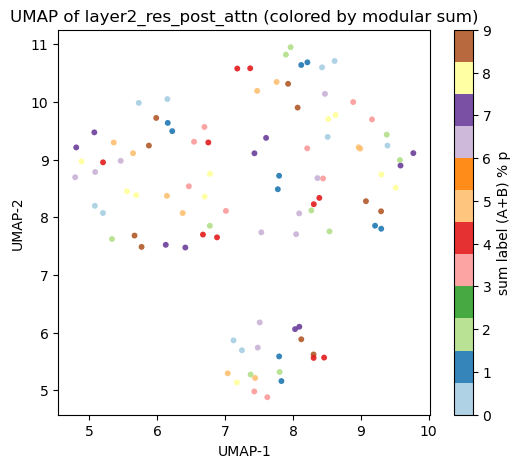

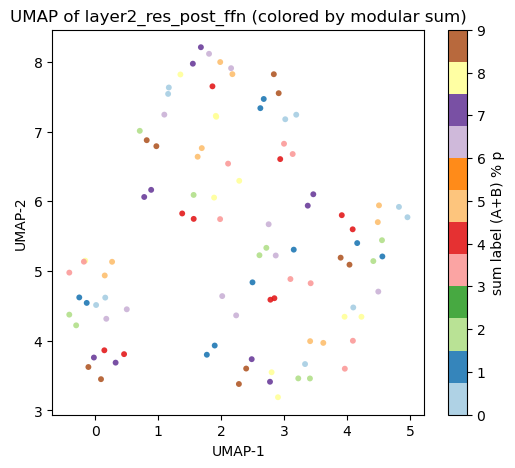

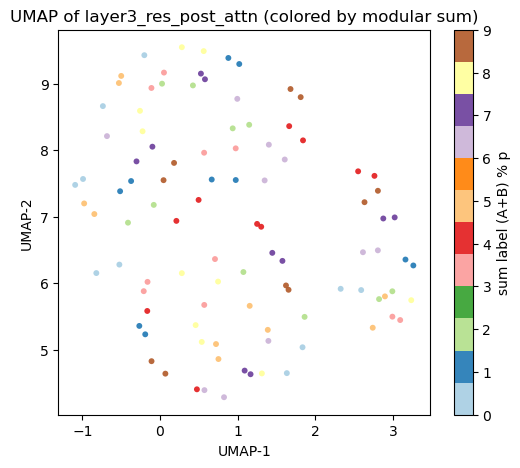

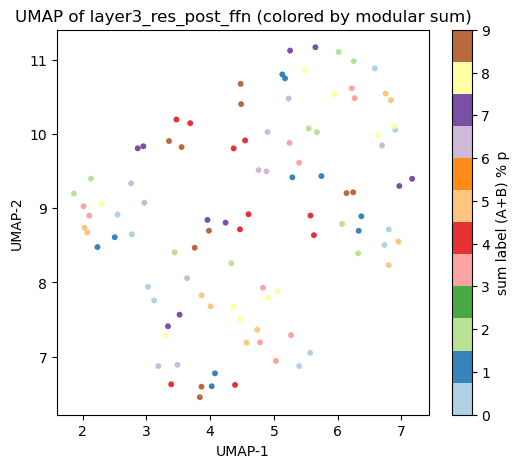

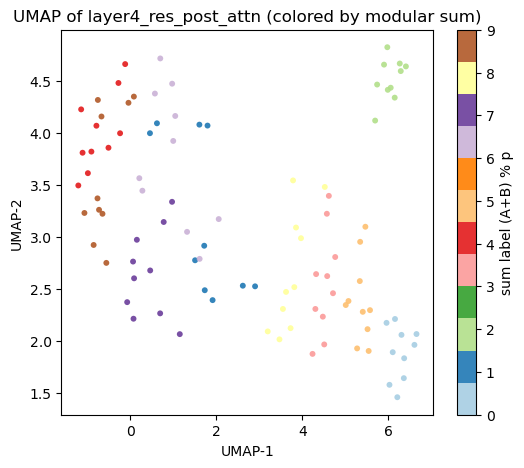

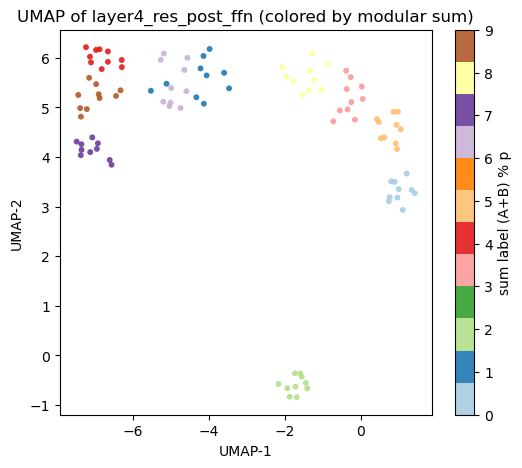

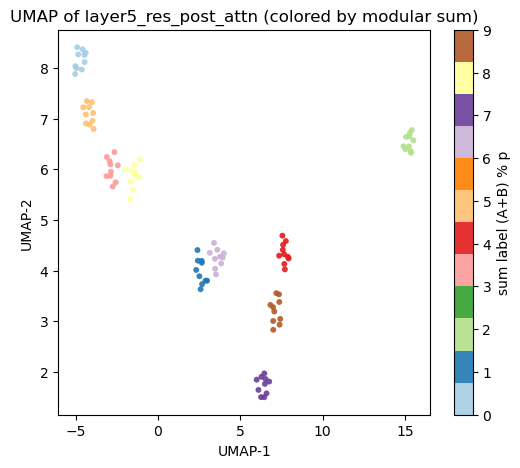

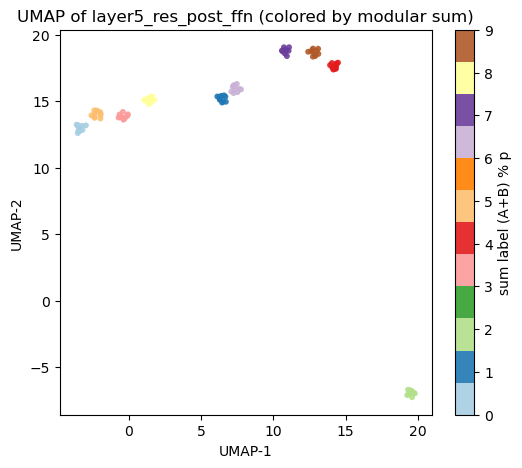

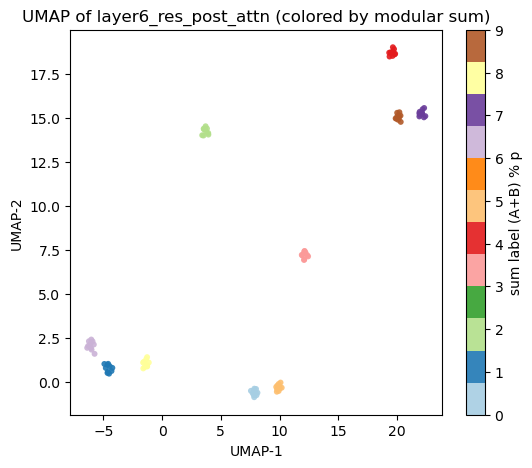

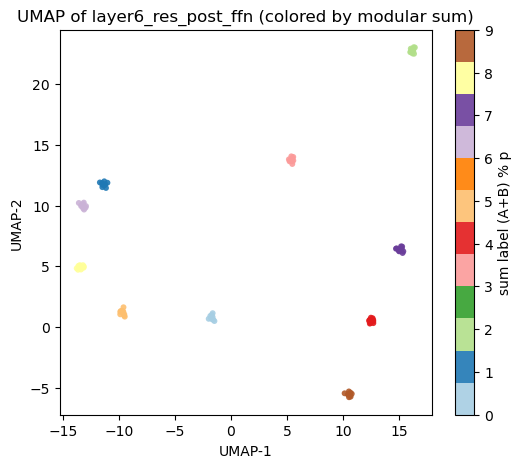

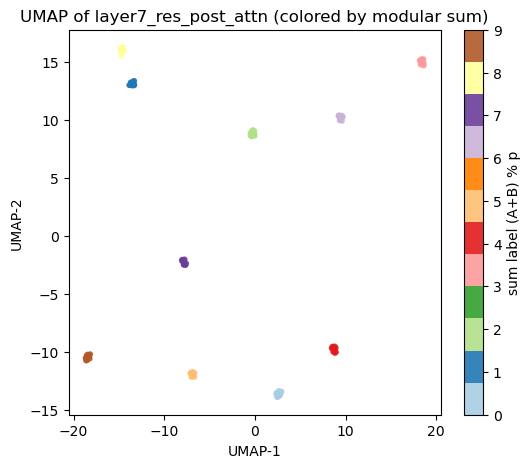

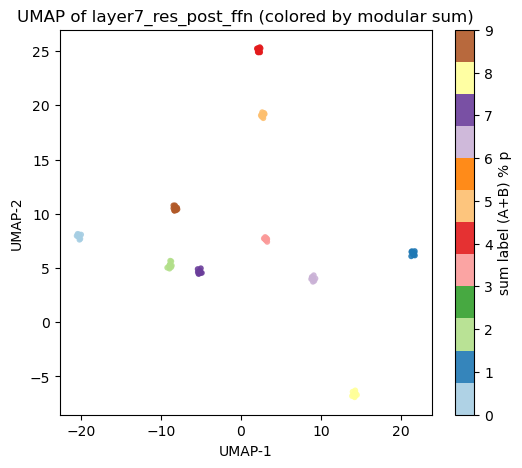

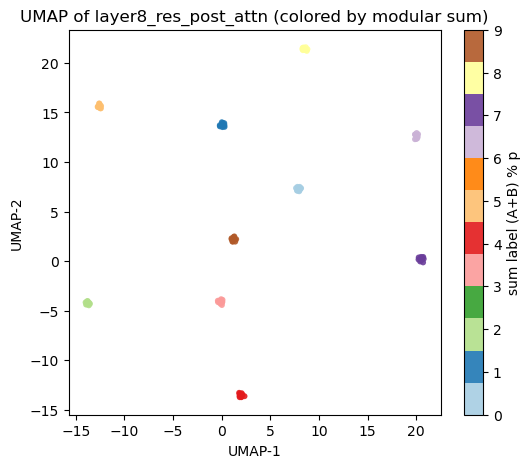

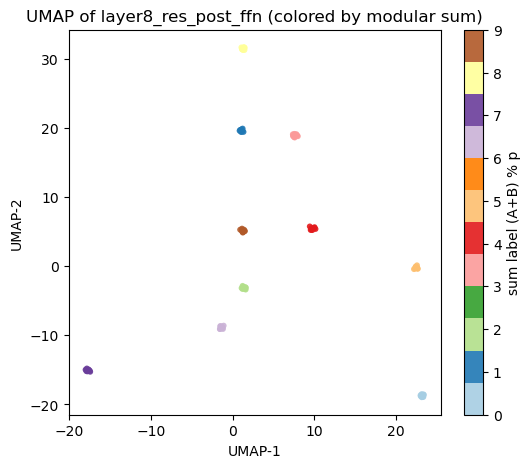

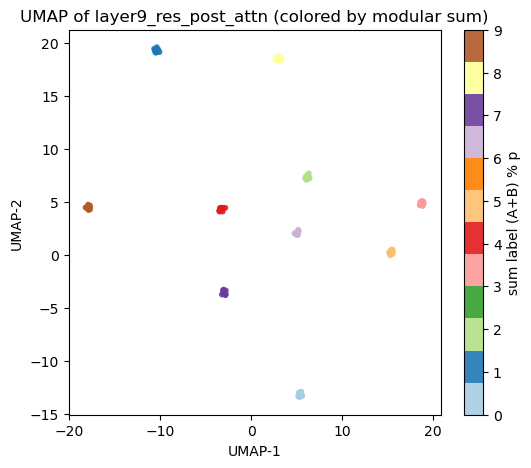

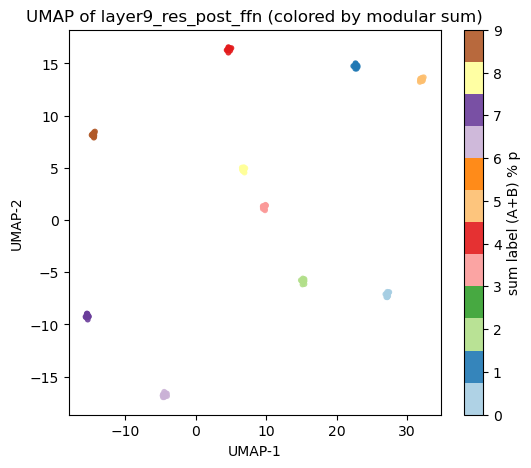

In [18]:
from umap import UMAP

# 1) Choose which activations to project
# key = "layer5_ffn_out"   # e.g., "layer5_ffn_out" or "layer5_attn_out"

keys = sorted(big.keys())

for key in keys:

    X = big[key]
    # If you stored full tensors ("none" reduction), shape is [N, T, D] → flatten tokens & features
    if X.ndim == 3:
        N, T, D = X.shape
        acts = X.reshape(N, T * D)
    elif X.ndim == 2:
        # if you used "token_mean" reduction: [N, D]
        acts = X
    else:
        raise ValueError(f"Unexpected activation shape {tuple(X.shape)} for key={key}")

    # 2) Build labels aligned with N (use the dataset directly so length matches N)
    # ds_val __getitem__ returns (x_tgt_gt, x_src, y_label)
    # labels = np.array([int(y.item()) for _, _, y in ds_val])  # should be length N
    labels = np.array([y for _, _, y in ds_full])
    # Labels are the first number in the modular sum (A + B) % p
    # labels = B_pred
    # labels = carry

    assert acts.shape[0] == labels.shape[0], f"Shape mismatch: X has {acts.shape[0]} rows, labels has {labels.shape[0]}"

    # 3) (Optional) standardize a bit to help UMAP (often helpful for cosine metric too)
    acts_centered = acts - acts.mean(axis=0, keepdims=True)

    # 4) Run UMAP
    umap = UMAP(
        n_neighbors=15,
        n_components=2,
        min_dist=0.1,
        metric="cosine",     # cosine often works well for high-dim representations
        random_state=None,
        n_jobs=-1,          # use all CPU cores
    )
    emb = umap.fit_transform(acts_centered)   # shape [N, 2]

    # 5) Plot
    plt.figure(figsize=(6,5))
    sc = plt.scatter(emb[:,0], emb[:,1], c=labels, cmap="Paired", s=18, alpha=0.9, edgecolors="none")
    cb = plt.colorbar(sc, ticks=sorted(np.unique(labels)))
    cb.set_label("sum label (A+B) % p")
    plt.title(f"UMAP of {key} (colored by modular sum)")
    plt.xlabel("UMAP-1"); plt.ylabel("UMAP-2")
    plt.tight_layout
    plt.show()

In [19]:
# Linear classification on X_flatten, trying to predict carry
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn import svm


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for key, X in big.items():
    print(f"Key: {key}")
    # flatten to [N, F]
    if hasattr(X, "reshape") and hasattr(X, "shape"):
        X_flat = X.reshape(X.shape[0], -1)
    else:
        # torch tensor fallback
        X_flat = X.view(X.size(0), -1).cpu().numpy()
    if hasattr(X_flat, "numpy"):
        X_np = X_flat.numpy()
    else:
        X_np = X_flat
    
    y = np.asarray(carry)
    assert X_np.shape[0] == y.shape[0], f"Mismatch N: {X_np.shape[0]} vs {y.shape[0]}"

    clf = make_pipeline(StandardScaler(), svm.SVC())
    scores = cross_val_score(clf, X_np, y, cv=cv, scoring="accuracy", n_jobs=-1)
    print(f"CV accuracy (n_splits={cv.get_n_splits()}): mean={scores.mean():.4f} std={scores.std():.4f}  scores={scores}")

Key: layer0_res_post_attn
CV accuracy (n_splits=5): mean=0.8000 std=0.0316  scores=[0.75 0.8  0.8  0.8  0.85]
Key: layer0_res_post_ffn
CV accuracy (n_splits=5): mean=0.7700 std=0.0245  scores=[0.75 0.75 0.75 0.8  0.8 ]
Key: layer1_res_post_attn
CV accuracy (n_splits=5): mean=0.8500 std=0.0316  scores=[0.85 0.9  0.85 0.8  0.85]
Key: layer1_res_post_ffn
CV accuracy (n_splits=5): mean=0.8700 std=0.0245  scores=[0.85 0.9  0.85 0.9  0.85]
Key: layer2_res_post_attn
CV accuracy (n_splits=5): mean=0.8400 std=0.0374  scores=[0.8  0.85 0.85 0.8  0.9 ]
Key: layer2_res_post_ffn
CV accuracy (n_splits=5): mean=0.8400 std=0.0374  scores=[0.8  0.85 0.85 0.8  0.9 ]
Key: layer3_res_post_attn
CV accuracy (n_splits=5): mean=0.8700 std=0.0748  scores=[0.75 0.95 0.85 0.85 0.95]
Key: layer3_res_post_ffn
CV accuracy (n_splits=5): mean=0.8800 std=0.0748  scores=[0.75 0.95 0.85 0.9  0.95]
Key: layer4_res_post_attn
CV accuracy (n_splits=5): mean=0.8700 std=0.0600  scores=[0.8  0.9  0.95 0.9  0.8 ]
Key: layer4_re

In [20]:
np.array([y for _, _, y in ds_full])

array([1, 8, 7, 9, 8, 2, 4, 8, 1, 0, 9, 3, 0, 6, 9, 4, 3, 4, 3, 4, 0, 6,
       8, 6, 5, 6, 4, 5, 9, 9, 2, 1, 3, 0, 2, 5, 2, 1, 8, 7, 3, 7, 7, 4,
       9, 0, 9, 7, 8, 4, 6, 3, 8, 1, 8, 5, 6, 0, 9, 7, 1, 8, 9, 7, 5, 3,
       0, 4, 7, 6, 6, 5, 3, 2, 7, 2, 2, 5, 3, 4, 9, 2, 0, 1, 1, 7, 3, 2,
       5, 5, 0, 1, 4, 0, 2, 6, 8, 5, 1, 6])

In [21]:
X.shape

torch.Size([100, 256, 256])

In [22]:
y = np.asarray(labels)
y

array([1, 8, 7, 9, 8, 2, 4, 8, 1, 0, 9, 3, 0, 6, 9, 4, 3, 4, 3, 4, 0, 6,
       8, 6, 5, 6, 4, 5, 9, 9, 2, 1, 3, 0, 2, 5, 2, 1, 8, 7, 3, 7, 7, 4,
       9, 0, 9, 7, 8, 4, 6, 3, 8, 1, 8, 5, 6, 0, 9, 7, 1, 8, 9, 7, 5, 3,
       0, 4, 7, 6, 6, 5, 3, 2, 7, 2, 2, 5, 3, 4, 9, 2, 0, 1, 1, 7, 3, 2,
       5, 5, 0, 1, 4, 0, 2, 6, 8, 5, 1, 6])

In [23]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn import svm

# big: dict of {layer_name: activations}, each value X has shape (N, T, D)
# labels: shape (N,), correct MNIST sums (0..9)

acc_results = {}  # to store results per layer

for key, X in big.items():
    print(f"\nLayer key: {key}")

    # --- convert to numpy, handle torch tensors too ---
    if hasattr(X, "detach"):  # torch tensor
        X_np = X.detach().cpu().numpy()
    elif hasattr(X, "numpy"):  # numpy-like
        X_np = X.numpy()
    else:
        X_np = np.asarray(X)

    if X_np.ndim != 3:
        raise ValueError(f"Expected X to have shape (N, T, D) but got {X_np.shape} for key {key}")

    N, T, D = X_np.shape
    y = np.array([y for _, _, y in ds_full])
    assert y.shape[0] == N, f"Mismatch N: X has {N} examples, labels has {y.shape[0]}"

    classes = np.unique(y)
    n_classes = len(classes)
    print(f"  N={N}, T={T}, D={D}, classes={classes}")

    # acc_matrix[token_index, class_index] = accuracy
    acc_matrix = np.zeros((T, n_classes), dtype=float)

    # for t in range(T):
    # Features from token position t across all examples: shape (N, D)
    X_tok = X_np.reshape(N*T, D)
    y = np.repeat(y, T)

    # SVM probe (RBF kernel by default)
    clf = make_pipeline(
        StandardScaler(),
        svm.SVC(decision_function_shape="ovr")
    )

    clf.fit(X_tok, y)
    y_pred = clf.predict(X_tok)

    # Per-class accuracy, per token
    for t in range(T):
        y_t = y[t::T]
        y_pred_t = y_pred[t::T]
        for j, c in enumerate(classes):
            mask = (y_t == c)
            if mask.sum() == 0:
                acc = np.nan  # just in case some class is missing
            else:
                acc = (y_pred_t[mask] == y_t[mask]).mean()
            acc_matrix[t, j] = acc

    acc_results[key] = {
        "classes": classes,        # mapping from col index -> class label
        "acc_matrix": acc_matrix,  # shape (T_tokens, n_classes)
    }
    print(f"Stored acc_matrix with shape {acc_matrix.shape} (tokens x classes)")



Layer key: layer0_res_post_attn
  N=100, T=256, D=256, classes=[0 1 2 3 4 5 6 7 8 9]
Stored acc_matrix with shape (256, 10) (tokens x classes)

Layer key: layer0_res_post_ffn
  N=100, T=256, D=256, classes=[0 1 2 3 4 5 6 7 8 9]
Stored acc_matrix with shape (256, 10) (tokens x classes)

Layer key: layer1_res_post_attn
  N=100, T=256, D=256, classes=[0 1 2 3 4 5 6 7 8 9]
Stored acc_matrix with shape (256, 10) (tokens x classes)

Layer key: layer1_res_post_ffn
  N=100, T=256, D=256, classes=[0 1 2 3 4 5 6 7 8 9]
Stored acc_matrix with shape (256, 10) (tokens x classes)

Layer key: layer2_res_post_attn
  N=100, T=256, D=256, classes=[0 1 2 3 4 5 6 7 8 9]
Stored acc_matrix with shape (256, 10) (tokens x classes)

Layer key: layer2_res_post_ffn
  N=100, T=256, D=256, classes=[0 1 2 3 4 5 6 7 8 9]
Stored acc_matrix with shape (256, 10) (tokens x classes)

Layer key: layer3_res_post_attn
  N=100, T=256, D=256, classes=[0 1 2 3 4 5 6 7 8 9]
Stored acc_matrix with shape (256, 10) (tokens x clas

In [24]:
# Save dict to disk
torch.save(acc_results, "activation_svm_accuracies_pertoken_residual.pt")
# acc_results

C:\Users\kingt\AppData\Local\Temp\ipykernel_23820\2947925706.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


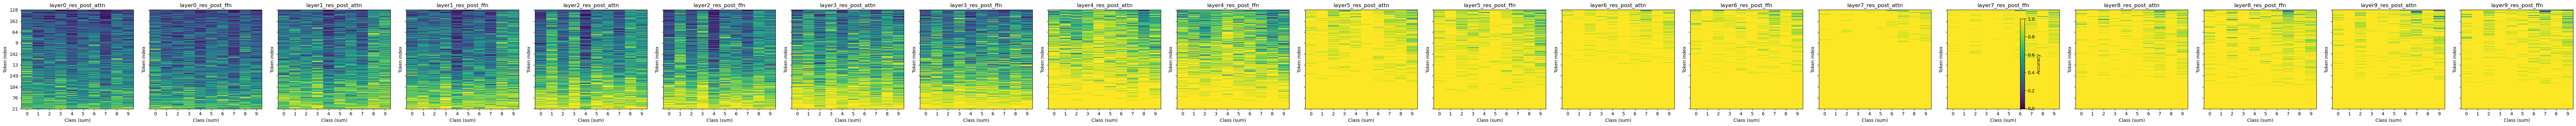

In [25]:
import numpy as np
import matplotlib.pyplot as plt

def plot_token_class_heatmaps(acc_results, sort_tokens=False, vmax=1.0):
    """
    For each layer in acc_results, plot a heatmap:
      y-axis: token index (or sorted by mean accuracy)
      x-axis: class (sum 0–9)
      color: per-class accuracy

    acc_results[key] must have:
      - "classes": array of class labels
      - "acc_matrix": shape (T_tokens, n_classes)
    """
    n_layers = len(acc_results)
    if n_layers == 0:
        print("No layers in acc_results!")
        return

    fig, axes = plt.subplots(
        1, n_layers,
        figsize=(4 * n_layers, 4),
        squeeze=False,
        sharey=True
    )
    axes = axes[0]

    for ax, (key, res) in zip(axes, acc_results.items()):
        acc = res["acc_matrix"]      # (T, C)
        classes = res["classes"]     # (C,)

        T, C = acc.shape
        tokens = np.arange(T)

        # Optionally sort tokens by their mean accuracy across classes
        if sort_tokens:
            mean_acc = acc.mean(axis=1)
            order = np.argsort(-mean_acc)  # descending
            acc_plot = acc[order]
            tokens_plot = tokens[order]
        else:
            acc_plot = acc
            tokens_plot = tokens

        im = ax.imshow(
            acc_plot,
            aspect="auto",
            origin="lower",
            vmin=0.0,
            vmax=vmax,
            interpolation="nearest",
        )

        ax.set_title(str(key))
        ax.set_xlabel("Class (sum)")
        ax.set_xticks(np.arange(C))
        ax.set_xticklabels(classes)

        ax.set_ylabel("Token index")
        # Only show a subset of y-ticks to keep it readable
        n_yticks = min(10, T)
        yticks = np.linspace(0, T - 1, n_yticks, dtype=int)
        ax.set_yticks(yticks)
        ax.set_yticklabels(tokens_plot[yticks])

    cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.9)
    cbar.set_label("Accuracy")

    plt.tight_layout()
    plt.show()


# Example usage:
# plot_token_class_heatmaps(acc_results, sort_tokens=False)
plot_token_class_heatmaps(acc_results, sort_tokens=True)  # see "best" tokens at top


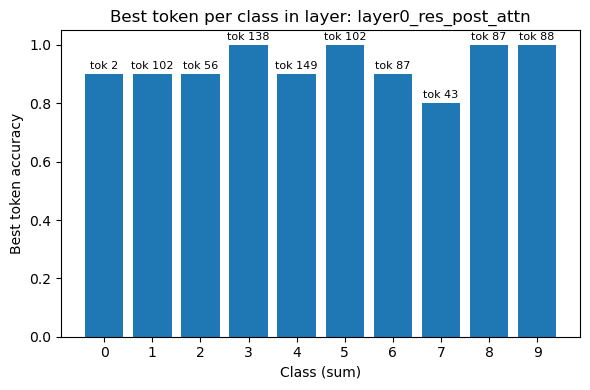

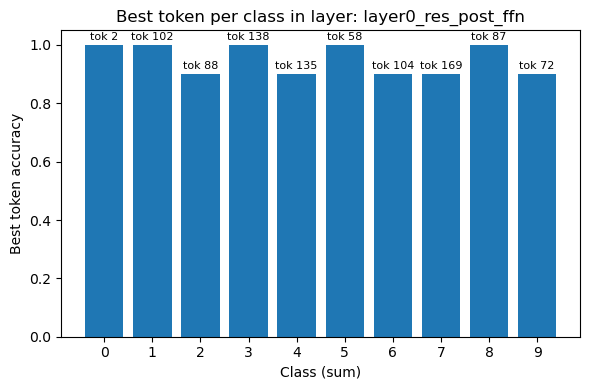

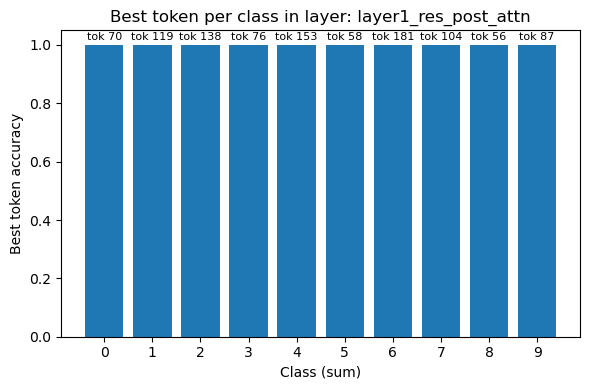

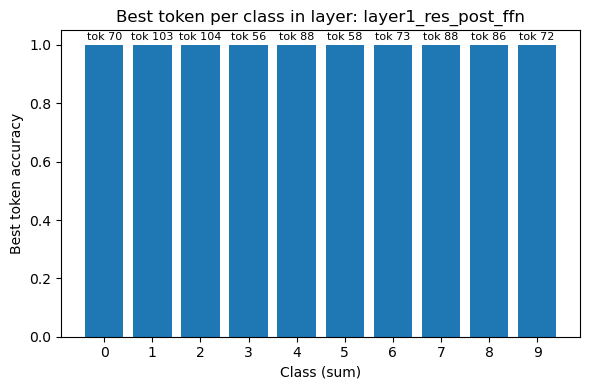

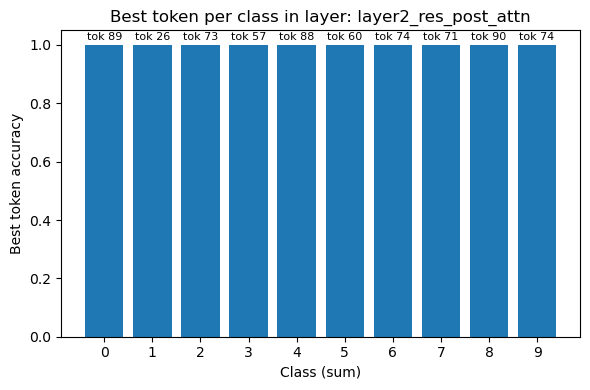

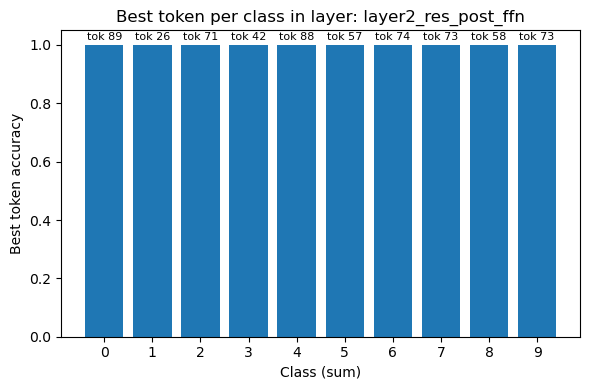

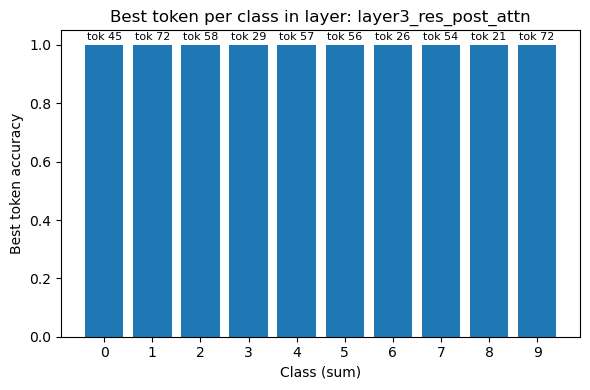

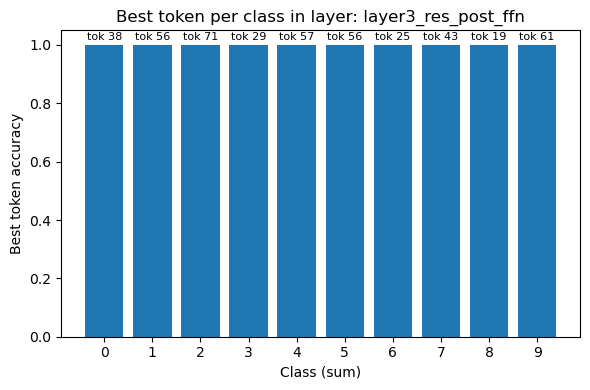

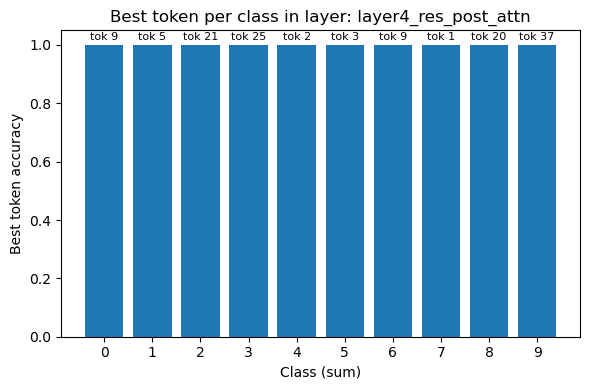

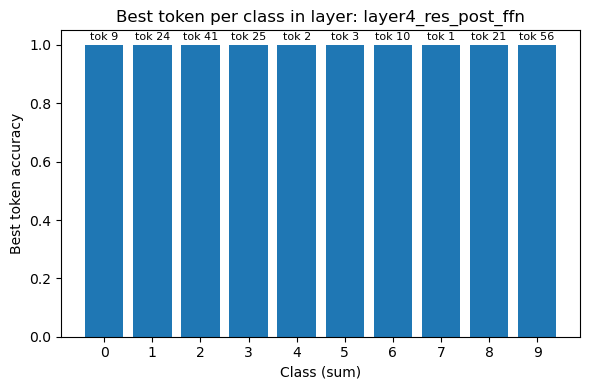

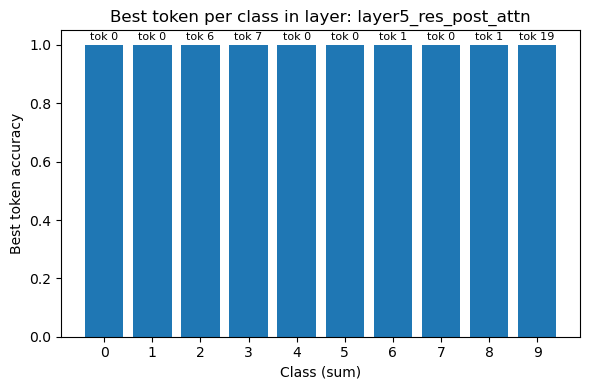

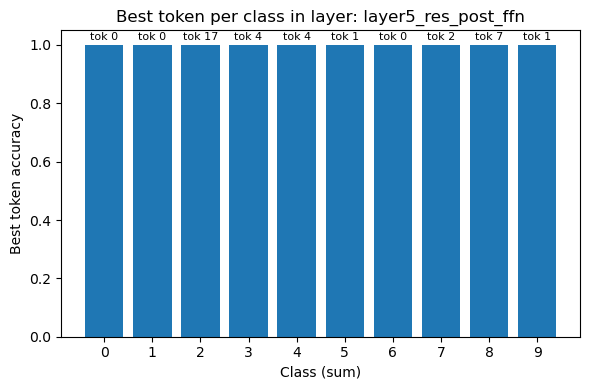

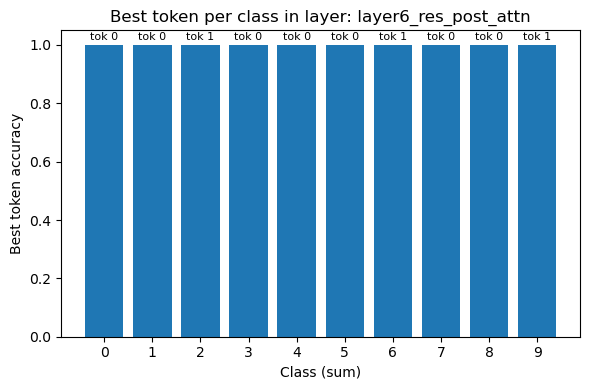

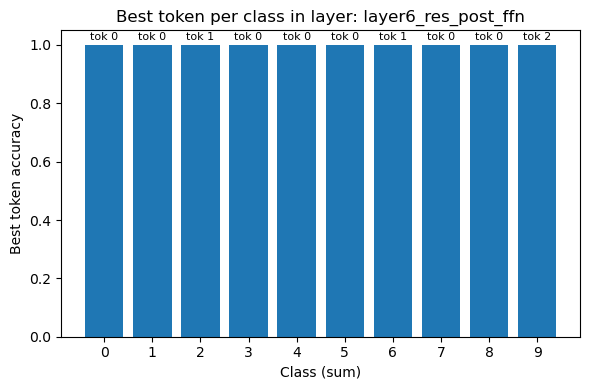

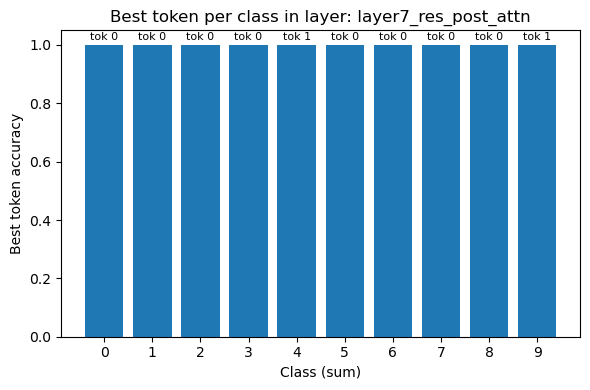

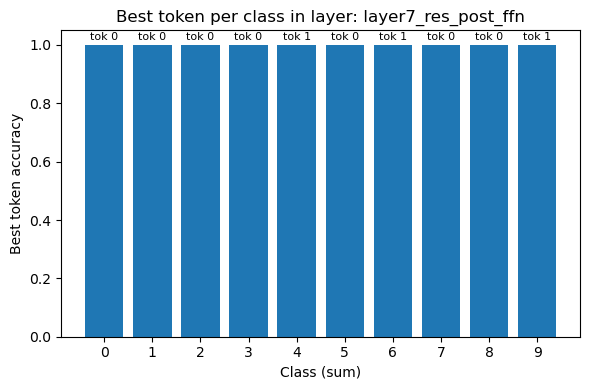

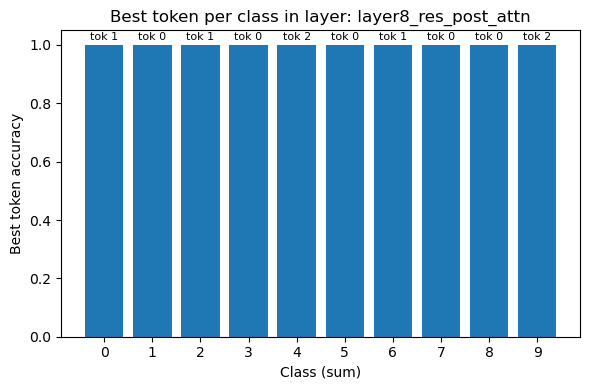

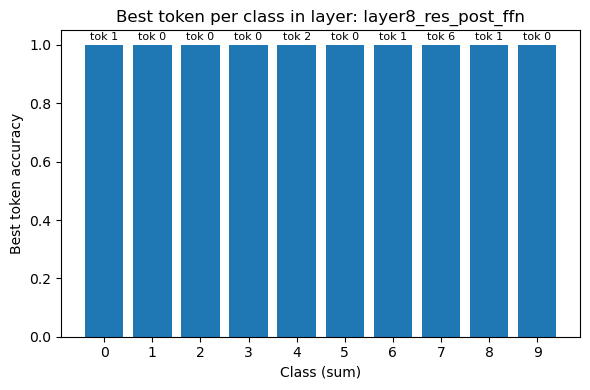

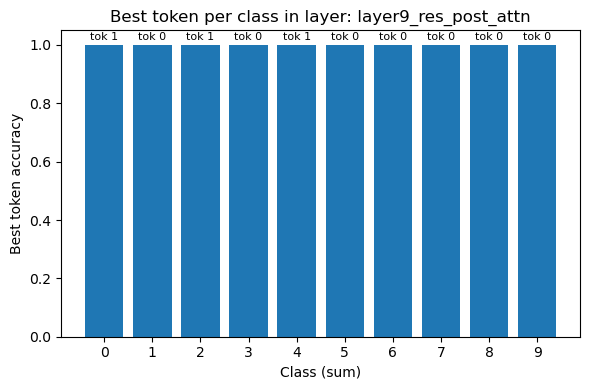

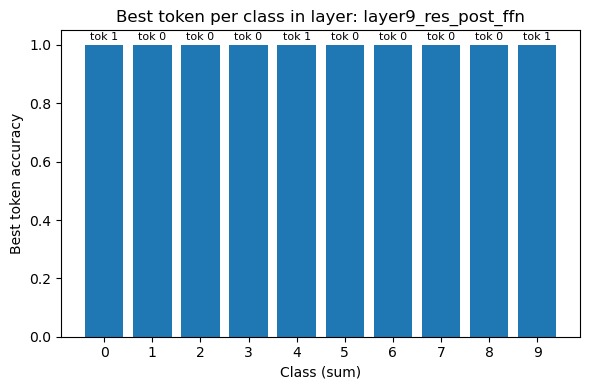

In [26]:
def plot_best_token_per_class(acc_results, layer_key):
    """
    For a single layer, show:
      - Bar height: best accuracy achieved for that class over all tokens
      - Text label above each bar: index of the best token for that class
    """
    res = acc_results[layer_key]
    acc = res["acc_matrix"]    # (T, C)
    classes = res["classes"]   # (C,)

    # Over tokens, per class
    best_token_idx = acc.argmax(axis=0)   # (C,)
    best_acc = acc.max(axis=0)           # (C,)

    x = np.arange(len(classes))

    plt.figure(figsize=(6, 4))
    plt.bar(x, best_acc)
    plt.xticks(x, classes)
    plt.xlabel("Class (sum)")
    plt.ylabel("Best token accuracy")
    plt.ylim(0, 1.05)
    plt.title(f"Best token per class in layer: {layer_key}")

    # Annotate token index above each bar
    for i, (t_idx, a) in enumerate(zip(best_token_idx, best_acc)):
        plt.text(i, a + 0.01, f"tok {t_idx}", ha="center", va="bottom", fontsize=8)

    plt.tight_layout()
    plt.show()


# Example:
for layer_key in acc_results.keys():
    plot_best_token_per_class(acc_results, layer_key=layer_key)

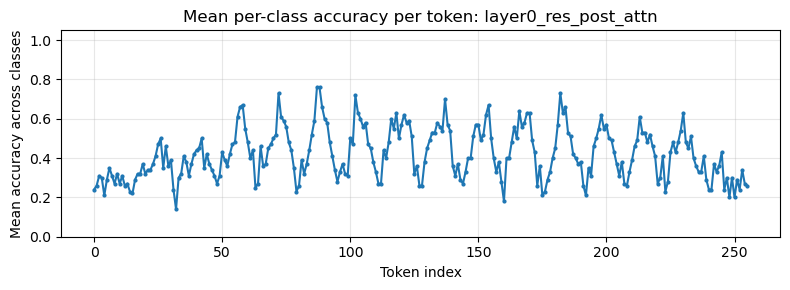

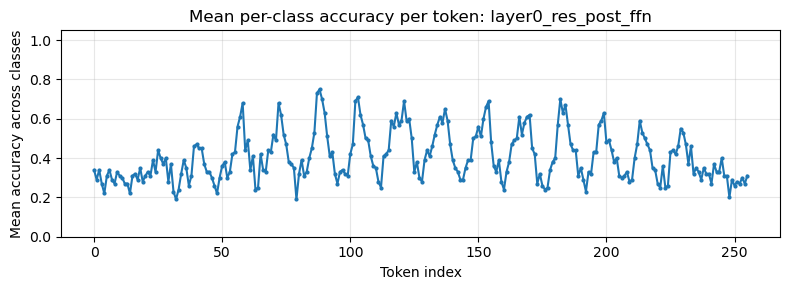

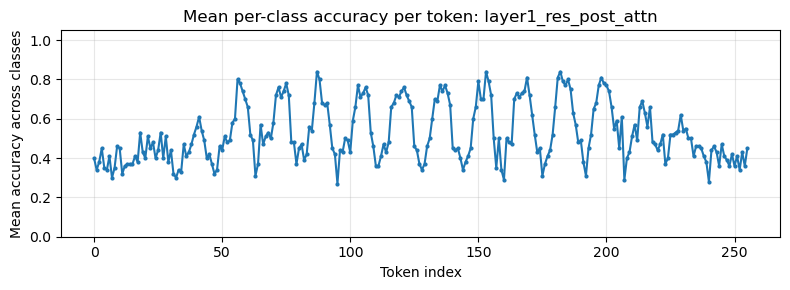

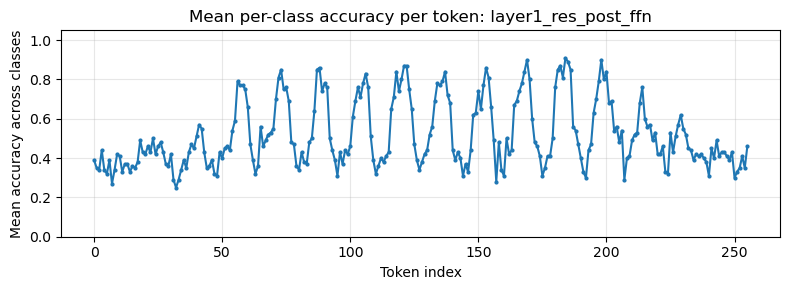

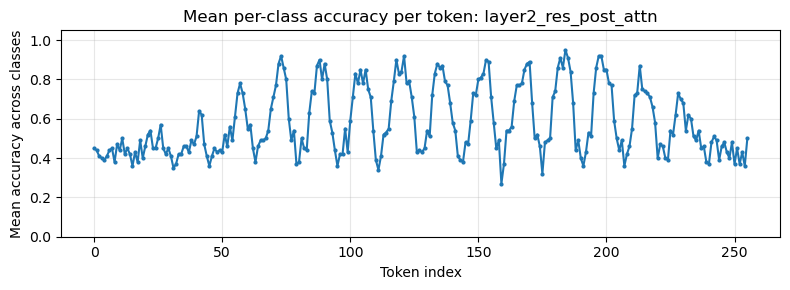

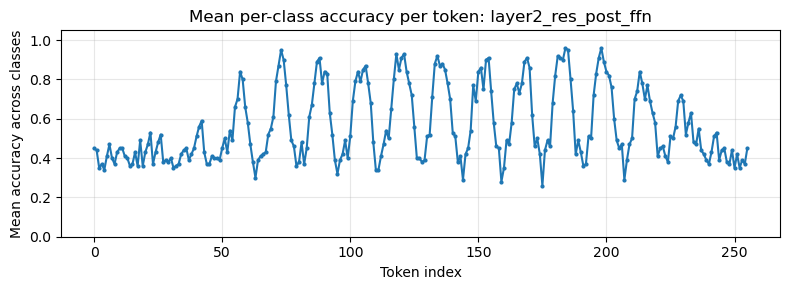

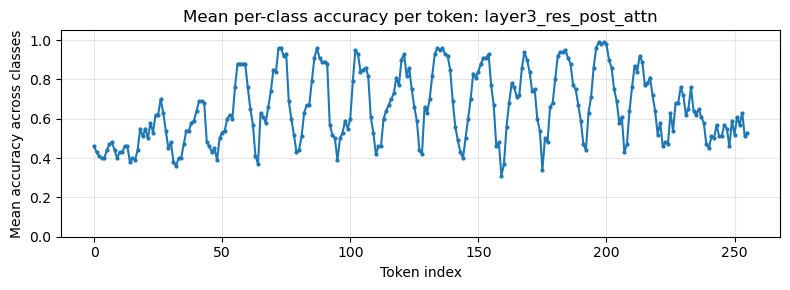

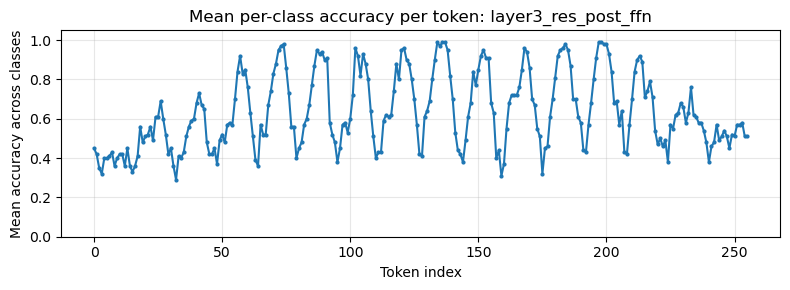

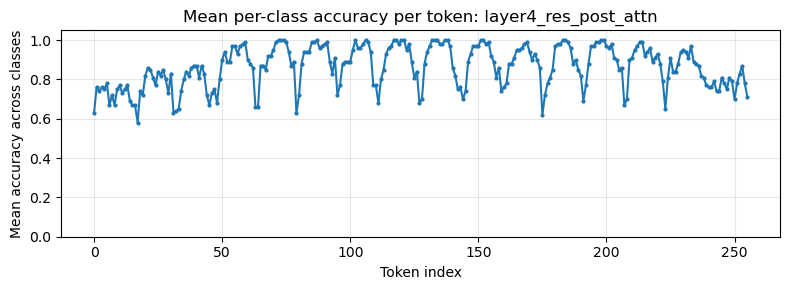

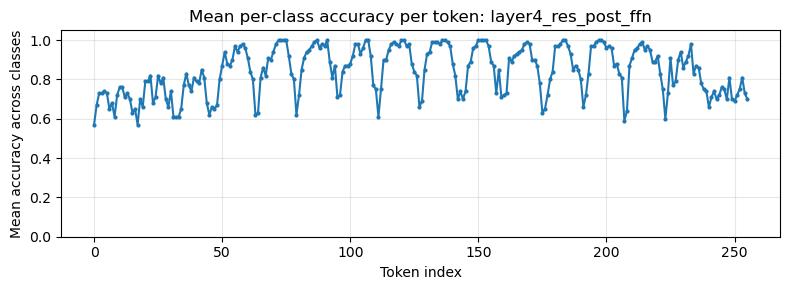

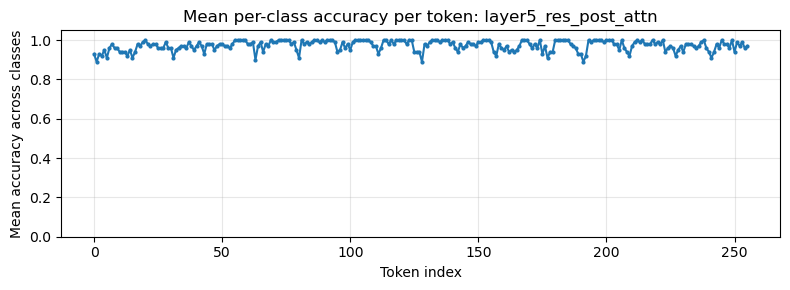

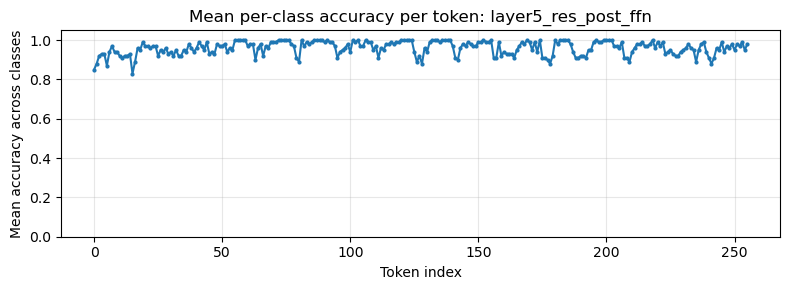

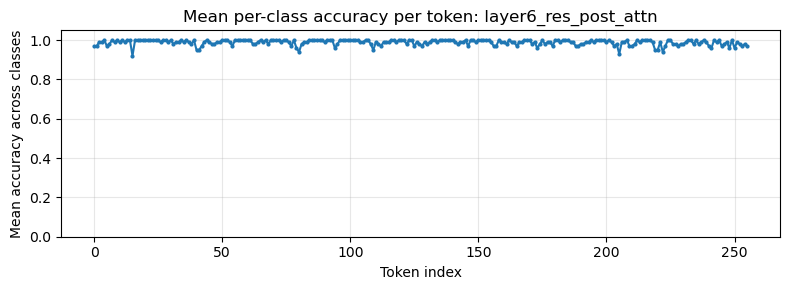

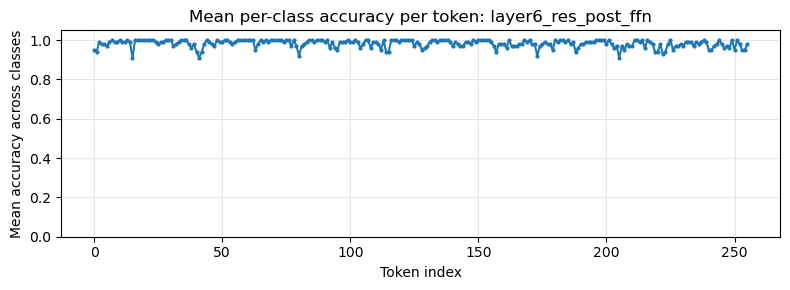

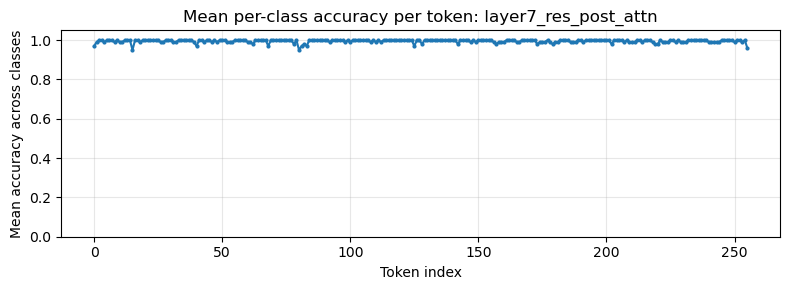

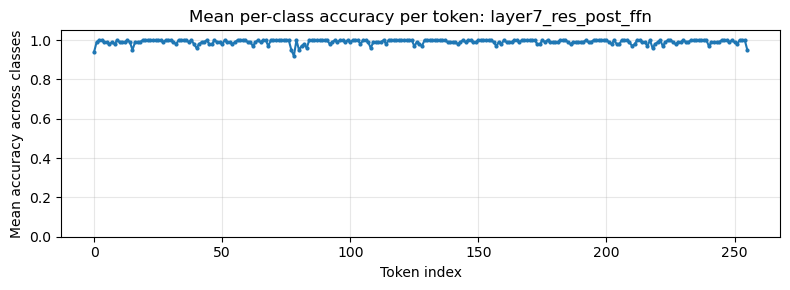

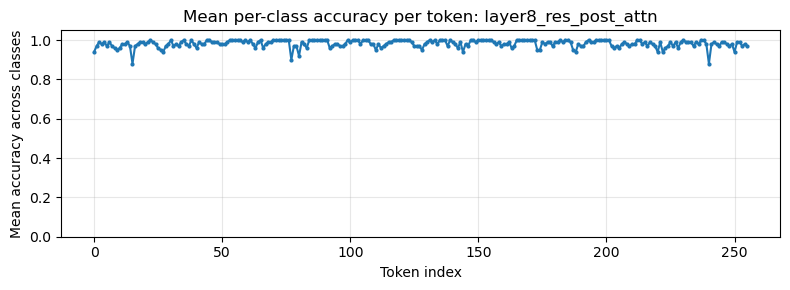

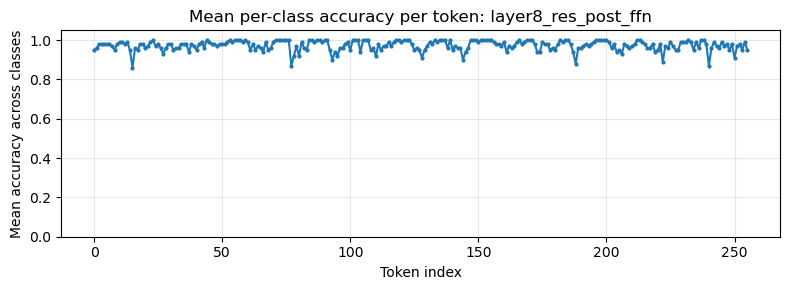

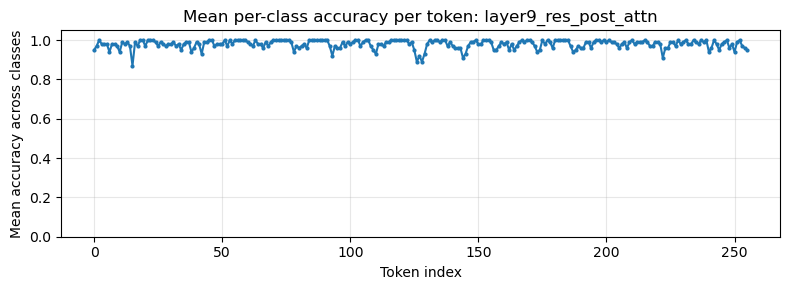

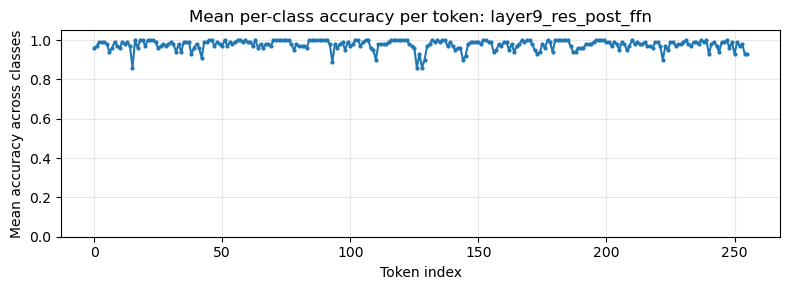

In [27]:
def plot_mean_accuracy_per_token(acc_results, layer_key):
    """
    For a single layer, plot the mean accuracy across classes per token.
    """
    res = acc_results[layer_key]
    acc = res["acc_matrix"]  # (T, C)
    T, C = acc.shape

    mean_acc_token = acc.mean(axis=1)  # (T,)

    plt.figure(figsize=(8, 3))
    plt.plot(np.arange(T), mean_acc_token, marker="o", linestyle="-", markersize=2)
    plt.xlabel("Token index")
    plt.ylabel("Mean accuracy across classes")
    plt.ylim(0, 1.05)
    plt.title(f"Mean per-class accuracy per token: {layer_key}")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# Example:
# plot_mean_accuracy_per_token(acc_results, layer_key="layer5_ffn_out")

for layer_key in acc_results.keys():
    plot_mean_accuracy_per_token(acc_results, layer_key=layer_key)

Using layers: ['layer0_res_post_attn', 'layer0_res_post_ffn', 'layer1_res_post_attn', 'layer1_res_post_ffn', 'layer2_res_post_attn', 'layer2_res_post_ffn', 'layer3_res_post_attn', 'layer3_res_post_ffn', 'layer4_res_post_attn', 'layer4_res_post_ffn', 'layer5_res_post_attn', 'layer5_res_post_ffn', 'layer6_res_post_attn', 'layer6_res_post_ffn', 'layer7_res_post_attn', 'layer7_res_post_ffn', 'layer8_res_post_attn', 'layer8_res_post_ffn', 'layer9_res_post_attn', 'layer9_res_post_ffn']


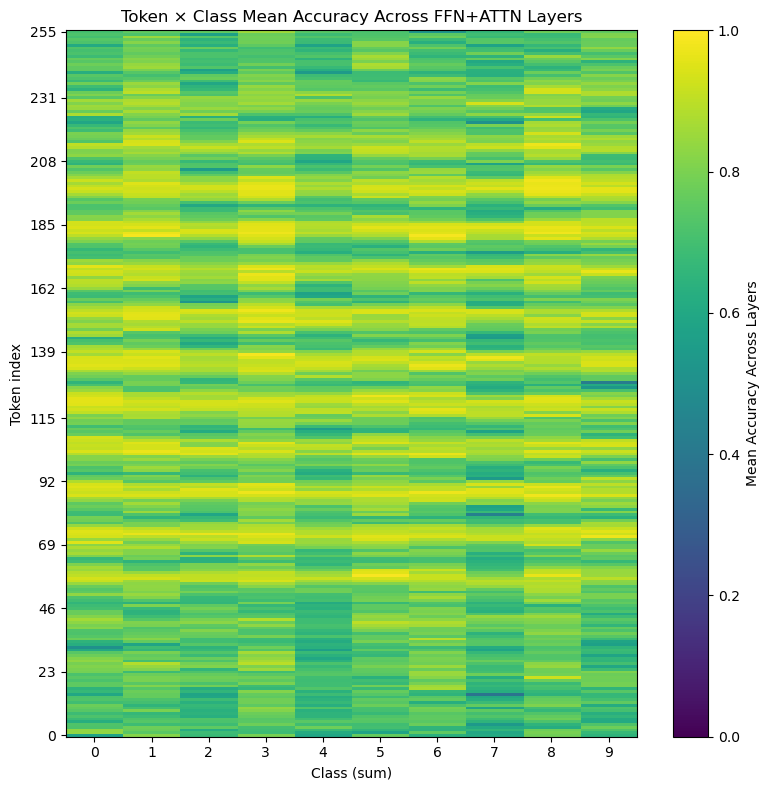

In [29]:
import numpy as np
import matplotlib.pyplot as plt

def compute_token_class_layer_mean(acc_results, layer_substrings=("ffn", "attn")):
    """
    Returns a (T_tokens, C_classes) matrix where each entry is:
        mean accuracy across selected layers
        for token index t and class c.
    """

    # --- Select layers (FFN + ATTN by default) ---
    selected_keys = [
        k for k in acc_results.keys()
        if any(sub in str(k).lower() for sub in layer_substrings)
    ]
    print("Using layers:", selected_keys)

    if not selected_keys:
        raise ValueError("No layers matched the provided substrings")

    # Use the first layer to get shape info
    first = acc_results[selected_keys[0]]
    classes = np.asarray(first["classes"])
    T, C = first["acc_matrix"].shape

    # Storage: accumulate per-layer accuracies
    acc_stack = np.zeros((len(selected_keys), T, C))

    # Fill stack
    for i, key in enumerate(selected_keys):
        acc_stack[i] = acc_results[key]["acc_matrix"]

    # Mean across layers
    acc_mean = acc_stack.mean(axis=0)   # (T, C)
    acc_std  = acc_stack.std(axis=0)    # optional: (T, C)

    return classes, acc_mean, acc_std

def plot_token_class_heatmap_mean(classes, acc_mean, vmax=1.0):
    """
    Heatmap: token index (rows) × class (columns)
    Values = mean accuracy across layers
    """

    T, C = acc_mean.shape

    plt.figure(figsize=(8, 8))
    im = plt.imshow(
        acc_mean,
        aspect='auto',
        origin='lower',
        vmin=0.0,
        vmax=vmax,
        cmap='viridis',
        interpolation="nearest"
    )

    plt.colorbar(im, label="Mean Accuracy Across Layers")
    plt.xlabel("Class (sum)")
    plt.ylabel("Token index")
    plt.title("Token × Class Mean Accuracy Across FFN+ATTN Layers")

    # tick formatting
    plt.xticks(np.arange(C), classes)
    # show limited y-ticks for readability
    yticks = np.linspace(0, T - 1, 12, dtype=int)
    plt.yticks(yticks, yticks)

    plt.tight_layout()
    plt.show()

classes, acc_mean, acc_std = compute_token_class_layer_mean(acc_results)

plot_token_class_heatmap_mean(classes, acc_mean)


In [ ]:
acc_results["layer0_attn_out"]["acc_matrix"]

array([[0.8, 0.9, 0.8, ..., 0.9, 0.8, 0.8],
       [0.9, 0.5, 0.7, ..., 0.7, 0.8, 0.6],
       [0.8, 0.6, 0.8, ..., 0.6, 0.7, 0.7],
       ...,
       [0.8, 0.6, 0.8, ..., 0.6, 0.8, 0.8],
       [0.6, 0.8, 0.8, ..., 0.8, 0.9, 0.8],
       [0.8, 1. , 0.8, ..., 0.9, 1. , 0.9]], shape=(256, 10))